# Fast-fourier Transform (FTT), Number-theoretic Transform (NTT) and Lattice-based Cryptography

The need to make systems and algorithms faster so as to make them more practical has been ever constant in the world of software engineering and cryptography at large, and lattice-based cryptography is not left out.

Number-theoretic Transform (NTT) was used in ML-KEM (Module-Lattice-Based Key-Encapsulation Mechanism), a lattice-based cryptographic algorithm used in establishing a shared secret key between two parties over a public channel. NTT is an analogue to the beautiful yet powerful Fast-fourier Transform (FTT).

The goal of this post is to take a deep dive into FFT, NTT and how NTT is used in ML-KEM. 

As always, we are going to take a discovery approach, building up slowly from the familiar to the unfamiliar.

## Fast-fourier Transform (FFT)

Given two polynomials $A$ and $B$ of degree 2 :
- $A = 3 - 4x + x^2$
- $B = 6 - 5x + x^2$

We are asked to multiply them. Easy, right?

- $C = A\ast B = (3 - 4x + x^2)(6 - 5x + x^2) = 3 * (6 - 5x + x^2) - 4x * (6 - 5x + x^2) + x^2 * (6 - 5x + x^2) = 18 + 39x + 29x^2 - 9x^3 + x^4$

Below is an implementation of this in Python:

```python
A = [3, -4, 1] # coefficients of A

B = [6, -5, 1] # coefficients of B

d = 2 # degree

C = [0 for _ in range((2 * d) + 1)]

for i in range(d + 1):
	for j in range(d + 1):
		C[i + j] = A[i] * B[j]
```

This algorithm takes $O(d^2)$ time. Is there a faster way to perform polynomial multiplication?

From the implementation above, you can tell that the polynomial is represented as a list of its *coefficients*. Are there other representations?

According to the **uniqueness theorem,** a polynomial of degree at most $d$ is uniquely determined by its values at $d + 1$ **distinct** points. That is, a polynomial $f(x)$ of degree $d$ can be uniquely constructed by the points: $(x_0, f(x_0)), (x_1, f(x_1)),...,(x_d, f(x_d))$. Let's call this representation **point representation**.

A more general version of the uniqueness theorem states that a polynomial of degree at most $d$ is uniquely determined by its values at *at least* $d + 1$ **distinct** points. That means we could uniquely represent our polynomial using more than $d + 1$ points.

Now, let's represent our polynomials using the point representation, using the values $x = -5, -4, -3, -2, -1$. Therefore, our polynomial can be represented as follows:


| $x$  | $A(x)$ | $B(x)$ | $(x, A(x))$ | $(x, B(x))$ |
| ---- | ------ | ------ | ----------- | ----------- |
| $-5$ | $48$   | $56$   | $(-5, 48)$  | $(-5, 56)$  |
| $-4$ | $35$   | $42$   | $(-4, 35)$  | $(-4, 42)$  |
| $-3$ | $24$   | $30$   | $(-3, 24)$  | $(-3, 30)$  |
| $-2$ | $15$   | $20$   | $(-2, 15)$  | $(-2, 20)$  |
| $-1$ | $8$    | $12$   | $(-1, 8)$   | $(-1, 12)$  |

Now, on to the interesting part. It turns out that $C(x_i) =A(x_i) \ast B(x_i)$. That is, if you multiply the evaluation $A(x_i)$ by the evaluation $B(x_i)$, you get the evaluation $C(x_i)$. See the table below:

| $x$  | $A(x)$ | $B(x)$ | $(x, A(x))$ | $(x, B(x))$ | $C(x) = A(x) * B(x)$ | $(x, C(x))$  |
| ---- | ------ | ------ | ----------- | ----------- | -------------------- | ------------ |
| $-5$ | $48$   | $56$   | $(-5, 48)$  | $(-5, 56)$  | $2688$               | $(-5, 2688)$ |
| $-4$ | $35$   | $42$   | $(-4, 35)$  | $(-4, 42)$  | $1470$               | $(-4, 1470)$ |
| $-3$ | $24$   | $30$   | $(-3, 24)$  | $(-3, 30)$  | $720$                | $(-3, 720)$  |
| $-2$ | $15$   | $20$   | $(-2, 15)$  | $(-2, 20)$  | $300$                | $(-2, 300)$  |
| $-1$ | $8$    | $12$   | $(-1, 8)$   | $(-1, 12)$  | $96$                 | $(-1, 96)$   |

This means that the points $(x, C(x))$ uniquely represents the polynomial $C = 18 + 39x + 29x^2 - 9x^3 + x^4$.

What does this all mean? We just achieved an $O(d)$ time polynomial multiplication by using the point representation form of the polynomials.

Does that mean we just achieved $O(d)$ for polynomial multiplication? Not really. 

Given two polynomials $f(x)$ and $g(x)$ of the form: $a_0 + a_1x + a_2x^2 + \cdots + a_{d}x^{d}$, here's the process:

1. **Convert from coefficient to point representation**: we pick a set of $x$ values and evaluate the polynomials at those points thereby converting the polynomials to the point representation.

   That is, we pick $x_i = \{x_0, x_1, ... ,x_n \}$ where $n$ is at least $d + 1$. Then, we compute $f(x_i) = \{f(x_0), f(x_1),...,f(x_n)\}$ and $g(x_i) = \{g(x_0), g(x_1),...,g(x_n)\}$.

   There's a way of expressing this in a matrix form:

   $$ V = \begin{bmatrix}x_0^0 & x_0^1 & x_0^2 & \cdots & x_0^{n} \\x_1^0 & x_1^1 & x_1^2 & \cdots & x_1^{n} \\[0.3em]\vdots & \vdots & \vdots & \ddots & \vdots \\[0.3em]x_n^0 & x^1_{n} & x_{n}^2 & \cdots & x_{n}^{n}\end{bmatrix} = \begin{bmatrix}1 & x_0^1 & x_0^2 & \cdots & x_0^{n} \\1 & x_1^1 & x_1^2 & \cdots & x_1^{n} \\[0.3em]\vdots & \vdots & \vdots & \ddots & \vdots \\[0.3em]1 & x^1_{n} & x_{n}^2 & \cdots & x_{n}^{n}\end{bmatrix}$$

   $$a = \begin{bmatrix}a_0 \\ a_1 \\ a_2 \\ \vdots \\ a_n\end{bmatrix}$$

   $$f(x_i) = \begin{bmatrix}f(x_0) \\ f(x_1) \\ f(x_2) \\ \vdots \\ f(x_n) \end{bmatrix}$$

   $$ Va = f(x_i)$$

   where $V$ is the matrix of $x_i$ and their powers, $a$ is a vector of coefficients and $f(x_i)$ are the evaluations. $V$ is called the **vandermonde** matrix.

   This shows that the process of evaluating the polynomial $f(x_i)$ is a *matrix-vector multiplication* which is an $O(n^2)$ operation and it will be helpful to use moving on.

   Using $A(x)$ as an example, choosing $n = 4$ and $x =\{x_0, x_1, x_2, x_3, x_4\}= \{-5, -4, -3, -2, -1\}$, we have the following:

   $$V = \begin{bmatrix}1 & x_0 & x_0^2 & x_0^3 & x_0^4 \\1 & x_1 & x_1^2 & x_1^3 & x_1^4 \\1 & x_2 & x_2^2 & x_2^3 & x_2^4 \\1 & x_3 & x_3^2 & x_3^3 & x_3^4 \\1 & x_4 & x_4^2 & x_4^3 & x_4^4 \end{bmatrix} = \begin{bmatrix}1 & -5 & -5^2 & -5^3 & -5^4 \\ 1 & -4 & -4^2 & -4^3 & -4^4 \\ 1 & -3 & -3^2 & -3^3 & -3^4 \\ 1 & -2 & -2^2 & -2^3 & -2^4 \\ 1 & -1 & -1^2 & -1^3 & -1^4 \end{bmatrix} = \begin{bmatrix}1 & -5 & 25 & -125 & 625 \\1 & -4 & 16 & -64 & 256 \\1 & -3 & 9 & -27 & 81 \\1 & -2 & 4 & -8 & 16 \\1 & -1 & 1 & -1 & 1\end{bmatrix}$$

   $$a = \begin{bmatrix}a_0 \\ a_1 \\ a_2 \\ a_3 \\ a_4\end{bmatrix} = \begin{bmatrix}3 \\ -4 \\ 1 \\ 0 \\ 0\end{bmatrix}$$

   $$Va = A(x_i) = \begin{bmatrix}A(x_0) \\ A(x_1) \\ A(x_2) \\ A(x_3) \\ A(x_4)\end{bmatrix} = \begin{bmatrix}48 \\ 35 \\ 24 \\ 15 \\ 8 \end{bmatrix}$$
   
2. **Multiply pairwise** (*i.e* $C(x) = A(x) \ast B(x)$). This runs in $O(n)$ time.
3. **Convert back from the point represention to the coefficient representation**: This is the reverse of step one. We want to find $a$, given $V$ and $f(x_i)$. To compute this, we find the **inverse of $V$** denoted by $V^{-1}$ and multiply by $f(x_i)$. That is:

   $$Va = f(x_i)$$

   $$V^{-1}Va = V^{-1}f(x_i)$$

   $$a = V^{-1}f(x_i)$$

   Using $A(x)$ as an example:

   $$V^{-1} = \begin{bmatrix}1 & -5 & 10 & -10 & 5 \\ 25/12 & -61/6 & 39/2 & -107/6 & 77/12 \\ 35/24 & -41/6 & 49/4 & -59/6 & 71/24 \\5/12 & -11/6 & 3 & -13/6 & 7/12 \\1/24 & -1/6 & 1/4 & -1/6 & 1/24 \end{bmatrix}$$

   $$A(x_i) = \begin{bmatrix}48 \\ 35 \\ 24 \\ 15 \\ 8 \end{bmatrix}$$

   $$a = V^{-1}A(x_i) = \begin{bmatrix}1 & -5 & 10 & -10 & 5 \\ 25/12 & -61/6 & 39/2 & -107/6 & 77/12 \\ 35/24 & -41/6 & 49/4 & -59/6 & 71/24 \\5/12 & -11/6 & 3 & -13/6 & 7/12 \\1/24 & -1/6 & 1/4 & -1/6 & 1/24 \end{bmatrix} \begin{bmatrix}48 \\ 35 \\ 24 \\ 15 \\ 8 \end{bmatrix} = \begin{bmatrix}3 \\ -4 \\ 1 \\ 0 \\ 0\end{bmatrix}$$

   The best version of this algorithm runs in $O(n^2)$ time.

In total, this process still takes $O(n^2)$ time. 

But, what if there was actually a faster way? A way that allows us to do polynomial multiplication in less than $O(n^2)$. 

Fast-fourier Transform (FFT) gives us that. FFT allows us to do step one and step three in $O(n\log n)$ time; making the whole process $O(n \log n)$ time.

To understand FFT, we need to understand the concept of **complex numbers** and **roots of unity**

### Complex Numbers and Roots of Unity

The magic of FFT is based on the beautiful concept of roots of unity but that in turn is only made possible by the unique properties of complex numbers. So, here's a deep dive on complex numbers.

Given the polynomial $P(x) = 1 + x + x^2$, find the roots(*i.e*, the values of $x$ for which $P(x) = 0$) of the polynomial? The simple answer is the roots does not exist.

Using the quadratic formula $x = \dfrac{-b \pm \sqrt{b^2 - 4ac}}{2a}$, let's solve anyways:
- $a = 1$, $b = 1$ and $c = 1$
- $x = \dfrac{-1 \pm \sqrt{1^2 - 4(1)(1)}}{2(1)} = \dfrac{-1 \pm \sqrt{-3}}{2} = \dfrac{-1}{2} \pm \dfrac{\sqrt{-3}}{2}$  
Therefore, the roots of $P(x)$ are $\dfrac{-1}{2} + \dfrac{\sqrt{-3}}{2}$ and $\dfrac{-1}{2} - \dfrac{\sqrt{-3}}{2}$.

But, we previously said the polynomial didn't have a root. How come we got two roots? The answer lies in the fact that from the beginning we have been dealing with real numbers $\mathbb{R}$ and the roots $\dfrac{-1}{2} + \dfrac{\sqrt{-3}}{2}$ and $\dfrac{-1}{2} - \dfrac{\sqrt{-3}}{2}$ are not real numbers. Therefore, the roots does not exist in real space. 

If the roots are not real numbers, then what are they? They are complex numbers!

Let's further simplify the roots. $\sqrt{-3}$ can be written $\sqrt{3} * \sqrt{-1}$. But, we know that $\sqrt{-1}$ is impossible to find. It has a special name, the *imaginary unit* denoted as $\mathrm{i}$.

We can rewrite our roots as follows: $\dfrac{-1}{2} + \dfrac{\sqrt{3}\mathrm{i}}{2}$ and $\dfrac{-1}{2} - \dfrac{\sqrt{3}\mathrm{i}}{2}$. Therefore, a complex number $\mathbb{C}$ is a number of the form: $a + b\mathrm{i}$ where $a$ and $b$ are real numbers and $\mathrm{i}$ is the imaginary unit. $a$ is called the *real part* and $b\mathrm{i}$ is called the *imaginary part*. This form of representing a complex number is called the *rectangular form*. You'll see why soon.

The set of real numbers $\mathbb{R}$ is a subset of the complex numbers $\mathbb{C}$ (*i.e*, $\mathbb{R} \subset \mathbb{C}$). Every real number can be written as a complex number where $b = 0$ (*e.g* $5 = 5 + 0\mathrm{i}$).

One way to describe a real number is as follows: a real number is any number that can be located on the infinite number line. That means, real numbers are represented on a number line as shown below.

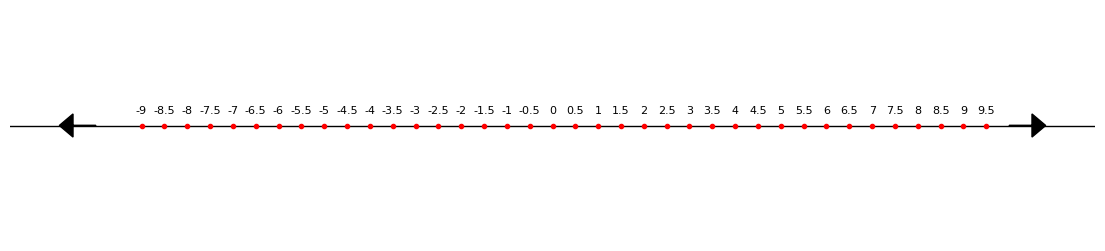

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure
plt.figure(figsize=(14, 3))

# Draw the number line
plt.axhline(0, color='black', linewidth=1)

# Add arrowheads to suggest infinity
plt.arrow(-10, 0, -0.5, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(10, 0, 0.5, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')

# Plot some points and labels
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

decimal_points = np.arange(-9, 10, 0.5)

for x in decimal_points:
    plt.plot(x, 0, 'ro', markersize=3)
    integers = [x for x in range(-9, 10)]
    text = str(x)
    if x in integers:
        text = str(int(x))
    plt.text(x, 0.1, text, ha='center', fontsize=8)

# Clean up y-axis
plt.yticks([])
plt.xticks([])
plt.ylim(-1, 1)
plt.show()


How do we represent a complex number? The number line would have been a good option but it would only be able to take the real part. We need diagram that allows us to show both the real part and the imaginary part. That's where the **Argand diagram** comes in!

The Argand diagram is two dimensional plane with the real part on the horinzontal line(x-axis) and the imaginary part on the vertical line (y-axis). 

For example, the complex number $2 + 3\mathrm{i}$ is represented as follows:

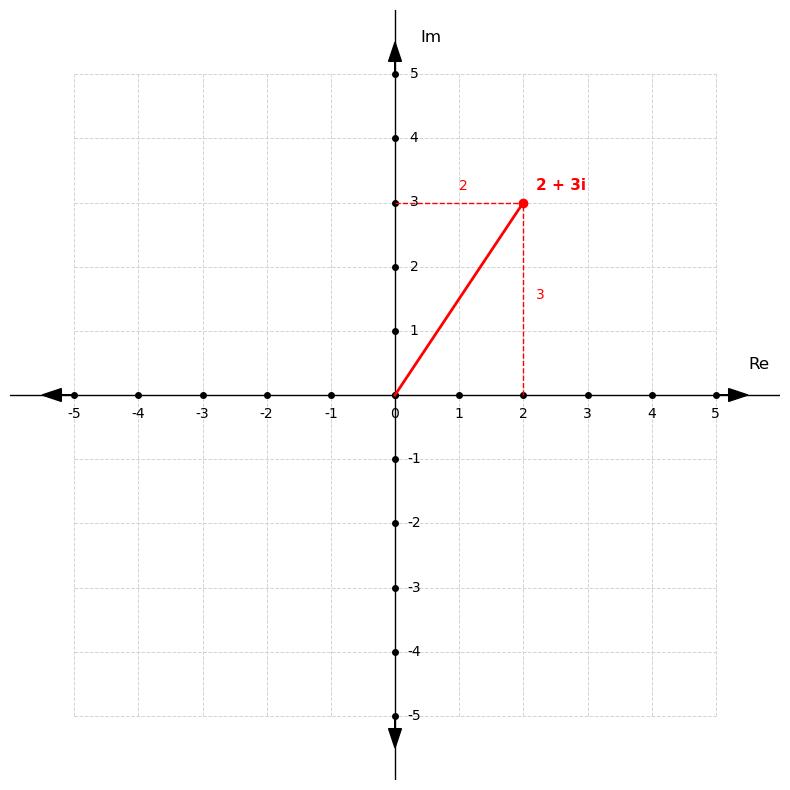

In [36]:
import matplotlib.pyplot as plt
import numpy as np

limit = 5
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- Plot 2 + 3i in rectangular form ---
z = 2 + 3j

# Dashed projection lines
plt.plot([z.real, z.real], [0, z.imag], 'r--', linewidth=1)  # vertical dashed line
plt.plot([0, z.real], [z.imag, z.imag], 'r--', linewidth=1)  # horizontal dashed line

# Hypotenuse (vector)
plt.plot([0, z.real], [0, z.imag], 'r-', linewidth=2)

# Point at (2,3)
plt.plot(z.real, z.imag, 'ro', markersize=6)

# Labels for sides
plt.text(z.real/2, z.imag + 0.2, "2", color='red', fontsize=10)  # base length
plt.text(z.real + 0.2, z.imag/2, "3", color='red', fontsize=10)  # height
plt.text(z.real + 0.2, z.imag + 0.2, "2 + 3i", color='red', fontsize=11, fontweight='bold')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()


Notice how the dotted lines from $2$ and $3$ forms a rectangle. That's why the form $a + b\mathrm{i}$ is called the *rectangular form*.

Imagine we were given the diagram with just the line from the origin as shown below. Would we be able to identify the complex number?

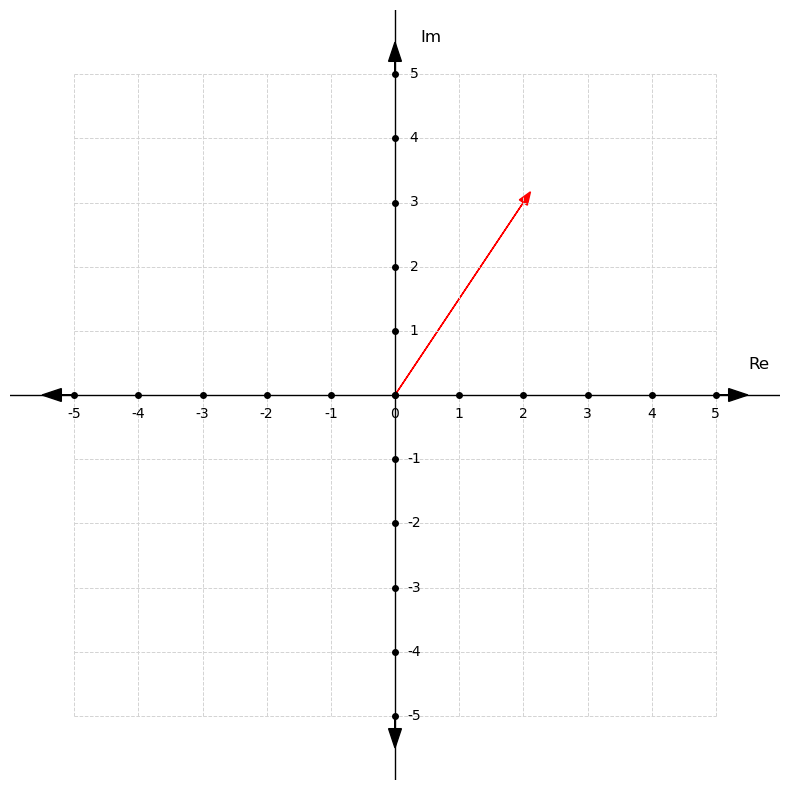

In [39]:
import matplotlib.pyplot as plt
import numpy as np

limit = 5
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- Plot and label the complex number 2 + 3i ---
z = 2 + 3j
plt.arrow(0, 0, z.real, z.imag, head_width=0.15, head_length=0.2, fc='red', ec='red') # vector 
# plt.plot(z.real, z.imag, 'ro', markersize=6)  # point
# plt.text(z.real + 0.2, z.imag + 0.2, "2 + 3i", color='red', fontsize=11, fontweight='bold')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()


Notice how the angle forms a *right angle triangle*. The diagram below should help.

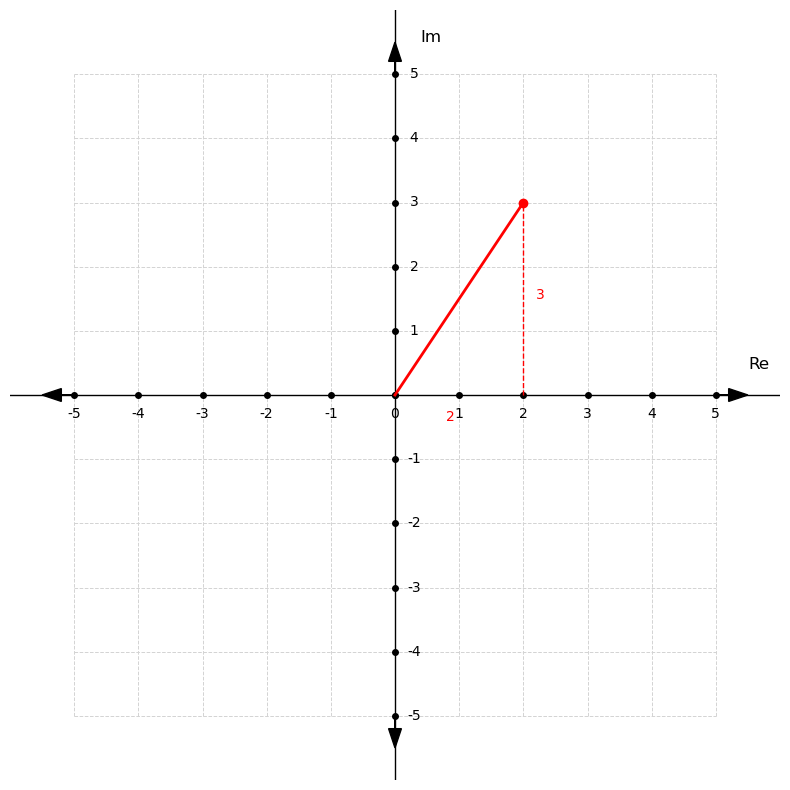

In [42]:
import matplotlib.pyplot as plt
import numpy as np

limit = 5
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- Plot 2 + 3i in rectangular form ---
z = 2 + 3j

# Dashed projection lines
plt.plot([z.real, z.real], [0, z.imag], 'r--', linewidth=1)  # vertical dashed line
# plt.plot([0, z.real], [z.imag, z.imag], 'r--', linewidth=1)  # horizontal dashed line

# Hypotenuse (vector)
plt.plot([0, z.real], [0, z.imag], 'r-', linewidth=2)

# Point at (2,3)
plt.plot(z.real, z.imag, 'ro', markersize=6)

# Labels for sides
plt.text(z.real/2 - 0.2, -0.4, "2", color='red', fontsize=10)  # base length
plt.text(z.real + 0.2, z.imag/2, "3", color='red', fontsize=10)  # height

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()


What do we know about right angle triangles?

According to the **Pythagoras Theorem**, in a right angled triangle, the square of the length of the hypotenuse(the side opposite the right angle) is equal to the sum of the squares of the lengths of the other two sides(*opposite* and *adjacent*). Mathematically, if a right-angled triangle has sides $a$ and $b$, and hypotenuse $c$, then: $c^2 = a^2 + b^2$.

Having known this; let's adjust out diagram.

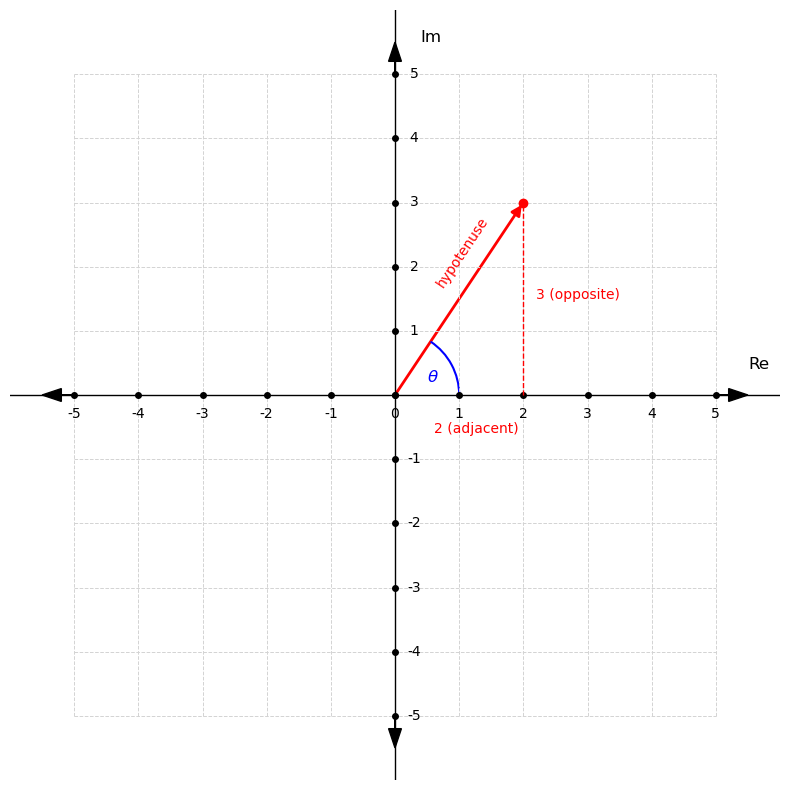

In [45]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc
import numpy as np

limit = 5
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Axis arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)
    plt.plot(0, t, 'ko', markersize=4)
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- Complex number ---
z = 2 + 3j
theta_rad = np.arctan2(z.imag, z.real)
theta_deg = np.degrees(np.arctan2(z.imag, z.real))

# Dashed projections (forming a right triangle)
plt.plot([z.real, z.real], [0, z.imag], 'r--', linewidth=1)

# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (z.real, z.imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=2)
ax.add_patch(arrow)

# --- Arc showing the angle θ ---
arc = Arc((0, 0), 2, 2, angle=0, theta1=0, theta2=theta_deg, color='blue', linewidth=1.5)
ax.add_patch(arc)
plt.text(0.5, 0.2, r"$\theta$", color='blue', fontsize=12)

# --- Point at z ---
plt.plot(z.real, z.imag, 'ro', markersize=6)

# Labels for components
plt.text(z.real/2 - 0.4, -0.6, "2 (adjacent)", color='red', fontsize=10)
plt.text(z.real + 0.2, z.imag/2, "3 (opposite)", color='red', fontsize=10)

# --- Place "hypotenuse" slightly above the line ---
# Midpoint of the vector
mid_x, mid_y = z.real / 2, z.imag / 2
# Perpendicular offset (rotate (dx,dy) by +90° and scale it)
offset = 0.3  # distance above line
dx = -np.sin(theta_rad) * offset
dy = np.cos(theta_rad) * offset
# Place text at midpoint + offset
plt.text(mid_x + dx, mid_y + dy, "hypotenuse", color='red', fontsize=10,
         rotation=theta_deg, rotation_mode='anchor')


# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

From the diagram, we can see that we have two unknowns the hypotenuse which will be denoted as $r$ and the angle $\theta$.

From pythagoras theorem, we know $r^2 = a^2 + b^2$. Therefore:$$r^2 = 2^2 + 3^2 = r^2 = 4 + 9 = 13$$
$$r = \sqrt{13}$$

Now we know $r$, how do we find $\theta$? Do you remember the acronym SOHCAHTOA from high school? This implies:
$$\sin\theta = \dfrac{\mathrm{opposite}}{\mathrm{hypotenuse}} = \dfrac{b}{r},\qquad b = r\sin\theta$$
$$\cos\theta = \dfrac{\mathrm{adjacent}}{\mathrm{hypotenuse}} = \dfrac{a}{r},\qquad a = r\cos\theta$$
$$\tan\theta = \dfrac{\mathrm{opposite}}{\mathrm{adjacent}} = \dfrac{b}{a}, \qquad \theta = \tan^{-1}(\dfrac{b}{a})$$

From this, we can deduce that: $a + b\mathrm{i} = r\cos\theta + \mathrm{i}r\sin\theta = r(\cos\theta + \mathrm{i}\sin\theta)$. This form of representing a complex number is called the *polar form*.

Now we find $\theta$ using $\tan^{-1}(\dfrac{b}{a})$, $\quad \theta = \tan^{-1}(\dfrac{3}{2}) = 0.983$ radians.

We have that $r = \sqrt{13}$ and $\theta = 0.983$. Given these two values, we represent the complex number $2 + 3\mathrm{i}$ as $\sqrt{13}(\cos(0.983) + \mathrm{i}\sin(0.983))$. $0.983$ radians is $56.3^\circ$ in degrees and it's better for visualization as shown below.

The polar representation might not be simplest way to express a complex number but it's going to help us understand roots of unity.

Formally, $r$ is distance from the point of the complex number to the origin and it is called the *modulus* or the *absolute value*. $\theta$ is called the *argument* of the complex number and it is the angle that the modulus $r$ makes with the positive real axis.

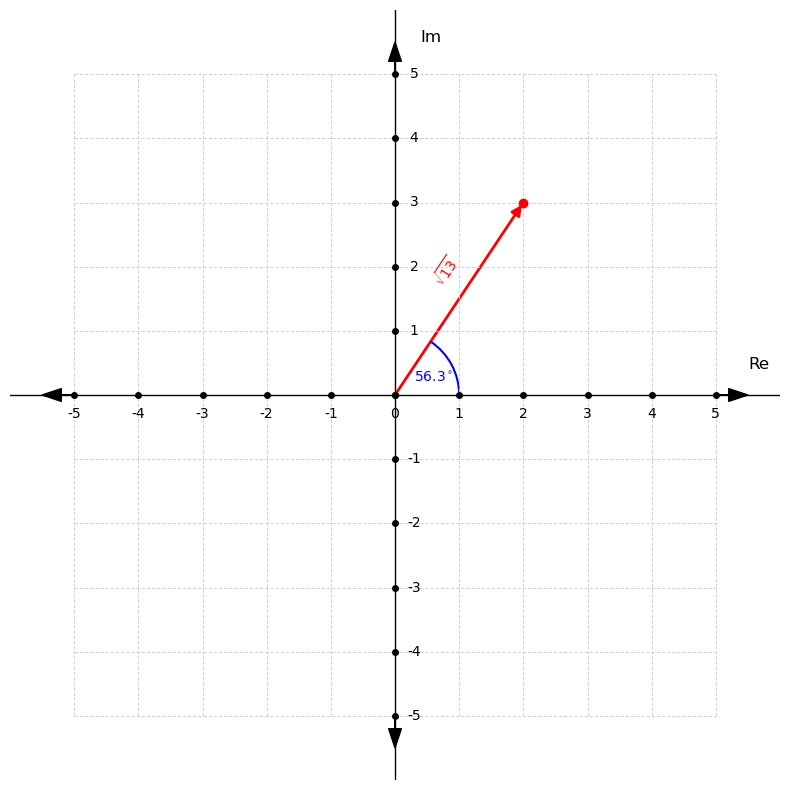

In [48]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Arc
import numpy as np

limit = 5
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Axis arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)
    plt.plot(0, t, 'ko', markersize=4)
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- Complex number ---
z = 2 + 3j
theta_deg = np.degrees(np.arctan2(z.imag, z.real))

# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (z.real, z.imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=2)
ax.add_patch(arrow)

# --- Arc showing the angle θ ---
arc = Arc((0, 0), 2, 2, angle=0, theta1=0, theta2=theta_deg, color='blue', linewidth=1.5)
ax.add_patch(arc)
plt.text(0.3, 0.2, r"$56.3^\circ$", color='blue', fontsize=10)

# --- Point at z ---
plt.plot(z.real, z.imag, 'ro', markersize=6)

# --- Place "hypotenuse" slightly above the line ---
# Midpoint of the vector
mid_x, mid_y = z.real / 2, z.imag / 2
# Perpendicular offset (rotate (dx,dy) by +90° and scale it)
offset = 0.3  # distance above line
dx = -np.sin(theta_rad) * offset
dy = np.cos(theta_rad) * offset
# Place text at midpoint + offset
plt.text(mid_x + dx, mid_y + dy, r"$\sqrt{13}$", color='red', fontsize=10,
         rotation=theta_deg, rotation_mode='anchor')


# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

Let's look at another representation of complex numbers.

Let's take a quick detour.

Have you ever wondered how calculators computed trignometric functions like $\sin(x)$, $\cos(x)$ and the exponential function $e^x$? The answer lies in approximation using power series.

$\cos(x)$ and $\sin(x)$ are approximated using the power series $1\ -\frac{x^{2}}{2!} + \frac{x^{4}}{4!} - \frac{x^{6}}{6!} + \frac{x^{8}}{8!} + \cdots$ and $x\ -\frac{x^{3}}{3!} + \frac{x^{5}}{5!} - \frac{x^{7}}{7!} + \frac{x^{9}}{9!} + \cdots$ respectively. I urge you to verify this using a graph(*i.e* compare their graphs while extending the series).

Let's substitute $\theta$ for $x$:

$$\cos(\theta) = 1\ - \frac{\theta^{2}}{2!} + \frac{\theta^{4}}{4!} - \frac{\theta^{6}}{6!} + \frac{\theta^{8}}{8!} + \cdots$$

$$\sin(\theta) = \theta\ - \frac{\theta^{3}}{3!} + \frac{\theta^{5}}{5!} - \frac{\theta^{7}}{7!} + \frac{\theta^{9}}{9!} + \cdots$$

Now, let's subsitute this approximation into the polar form:

$$\cos\theta + \mathrm{i}\sin\theta = (1\ - \frac{\theta^{2}}{2!} + \frac{\theta^{4}}{4!} - \frac{\theta^{6}}{6!} + \frac{\theta^{8}}{8!} + \cdots) + \mathrm{i}(\theta\ - \frac{\theta^{3}}{3!} + \frac{\theta^{5}}{5!} - \frac{\theta^{7}}{7!} + \frac{\theta^{9}}{9!} + \cdots)$$

$$ \qquad  \qquad  = (1\ - \frac{\theta^{2}}{2!} + \frac{\theta^{4}}{4!} - \frac{\theta^{6}}{6!} + \frac{\theta^{8}}{8!} + \cdots) + (\mathrm{i}\theta\ - \mathrm{i}\frac{\theta^{3}}{3!} + \mathrm{i}\frac{\theta^{5}}{5!} - \mathrm{i}\frac{\theta^{7}}{7!} + \mathrm{i}\frac{\theta^{9}}{9!} + \cdots)$$

$$ \qquad  \qquad  = 1\ + \mathrm{i}\theta - \frac{\theta^{2}}{2!} - \mathrm{i}\frac{\theta^{3}}{3!} + \frac{\theta^{4}}{4!} + \mathrm{i}\frac{\theta^{5}}{5!} - \frac{\theta^{6}}{6!} - \mathrm{i}\frac{\theta^{7}}{7!} + \frac{\theta^{8}}{8!} + \mathrm{i}\frac{\theta^{9}}{9!} + \cdots$$

Let's look at that of the exponential function $e^x$. The power series for $e^x$ as follows:  $$1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \frac{x^4}{4!} + \frac{x^5}{5!} + \frac{x^6}{6!} + \frac{x^7}{7!} + \frac{x^8}{8!} + \frac{x^9}{9!} \cdots$$

Let's substitute $\mathrm{i}\theta$ for $x$: $$ e^{\mathrm{i}\theta} = 1 + \mathrm{i}\theta + \frac{(\mathrm{i}\theta)^2}{2!} + \frac{(\mathrm{i}\theta)^3}{3!} + \frac{(\mathrm{i}\theta)^4}{4!} + \frac{(\mathrm{i}\theta)^5}{5!} + \frac{(\mathrm{i}\theta)^6}{6!} + \frac{(\mathrm{i}\theta)^7}{7!} + \frac{(\mathrm{i}\theta)^8}{8!} + \frac{(\mathrm{i}\theta)^9}{9!} + \cdots$$

We will compute the powers of $(\mathrm{i}\theta)$. From indices we know that $(\mathrm{i}\theta)^n = \theta^n\mathrm{i}^n$. Let's focus on $\mathrm{i}^n$:
- $\mathrm{i}^1 = \mathrm{i}$
- $\mathrm{i}^2 = \sqrt{-1} \ast \sqrt{-1} = -1$
- $\mathrm{i}^3 = \sqrt{-1} \ast \sqrt{-1} \ast \sqrt{-1} = -1 \ast \sqrt{-1} =  -\mathrm{i}$
- $\mathrm{i}^4 = \sqrt{-1} \ast \sqrt{-1} \ast \sqrt{-1} \ast \sqrt{-1} = -1 \ast -1 = 1$
- $\mathrm{i}^5 = \mathrm{i}$
- $\mathrm{i}^6 = -1$
- $\mathrm{i}^7 = -\mathrm{i}$
- $\mathrm{i}^8 = 1$
- $\mathrm{i}^9 = \mathrm{i}$

Do you see the pattern? The values are cyclic in nature; $\mathrm{i}$ to $1$, it repeats and continues like that. We will come back to this but for now let's go back to computing $e^{\mathrm{i}\theta}$. It now becomes: $$e^{\mathrm{i}\theta} = 1 + \mathrm{i}\theta - \frac{\theta^2}{2!} - \frac{\mathrm{i}\theta^3}{3!} + \frac{\theta^4}{4!} + \frac{\mathrm{i}\theta^5}{5!} - \frac{\theta^6}{6!} - \frac{\mathrm{i}\theta^7}{7!} + \frac{\theta^8}{8!} + \frac{\mathrm{i}\theta^9}{9!} + \cdots$$

From this we can see that $e^{\mathrm{i}\theta} = \cos(\theta) + \mathrm{i}\sin(\theta)$. Therefore, we have our third representation, the *exponential form*: $re^{\mathrm{i}\theta}$.

In summary, we have:
- rectangular form: $a + b\mathrm{i}$
- polar form: $r(\cos(\theta) + \mathrm{i}\sin(\theta))$
- exponential form: $re^{\mathrm{i}\theta}$

Soon, you will see why exponential and polar form are best suited for understanding and working with roots of unity.

Now, back to the where this it all started: finding the roots of the polynomial $P(x) = 1 + x + x^2$. We saw that the roots are $\dfrac{-1}{2} + \dfrac{\sqrt{3}\mathrm{i}}{2}$ and $\dfrac{-1}{2} - \dfrac{\sqrt{3}\mathrm{i}}{2}$.

Let's represent them using the argand diagram.

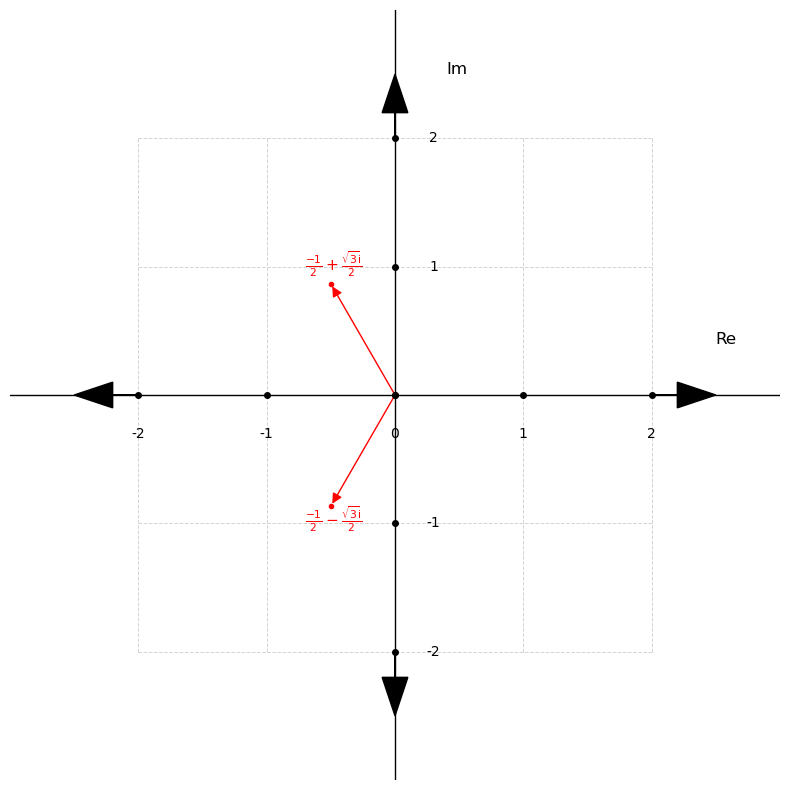

In [51]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [-1/2 + ((sqrt(3)/2) * 1j), -1/2 - ((sqrt(3)/2) * 1j)]

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=3)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)

# Labels for sides
plt.text(roots[0].real - 0.2, roots[0].imag + 0.1, r"$\frac{-1}{2} + \frac{\sqrt{3}\mathrm{i}}{2}$", color='red', fontsize=11, fontweight='bold')
plt.text(roots[1].real - 0.2, roots[1].imag - 0.15, r"$\frac{-1}{2} - \frac{\sqrt{3}\mathrm{i}}{2}$", color='red', fontsize=11, fontweight='bold')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

Let's find the modulus $r$ and the argument $\theta$ of these roots:
- For $\dfrac{-1}{2} + \dfrac{\sqrt{3}\mathrm{i}}{2}$:
  - finding $r$: $r^2 = a^2 + b^2$, $\quad a = \dfrac{-1}{2}$, $\quad b =  \dfrac{\sqrt{3}}{2}$, $\quad r^2 = (\dfrac{-1}{2})^2 + (\dfrac{\sqrt{3}}{2})^2 = \dfrac{1}{4} + \dfrac{3}{4} = \dfrac{4}{4} = 1$, $\quad r = 1$
  - finding $\theta$: $\theta = \tan^{-1}(\dfrac{b}{a}) = \tan^{-1}(\dfrac{\dfrac{\sqrt{3}}{2}}{\dfrac{-1}{2}}) = \tan^{-1}(\dfrac{\sqrt{3}}{-1}) = \tan^{-1}(-\sqrt{3}) = -60^\circ$ or $-\dfrac{\pi}{3}$
- For $\dfrac{-1}{2} - \dfrac{\sqrt{3}\mathrm{i}}{2}$:
  - finding $r$: $r^2 = a^2 + b^2$, $\quad a = \dfrac{-1}{2}$, $\quad b =  \dfrac{-\sqrt{3}}{2}$, $\quad r^2 = (\dfrac{-1}{2})^2 + (\dfrac{-\sqrt{3}}{2})^2 = \dfrac{1}{4} + \dfrac{3}{4} = \dfrac{4}{4} = 1$, $\quad r = 1$
  - finding $\theta$: $\theta = \tan^{-1}(\dfrac{b}{a}) = \tan^{-1}(\dfrac{\dfrac{-\sqrt{3}}{2}}{\dfrac{-1}{2}}) = \tan^{-1}(\dfrac{-\sqrt{3}}{-1}) = \tan^{-1}(\sqrt{3}) = 60^\circ$ or $\dfrac{\pi}{3}$

Let's show our $r$ and $\theta$ values to our diagram.

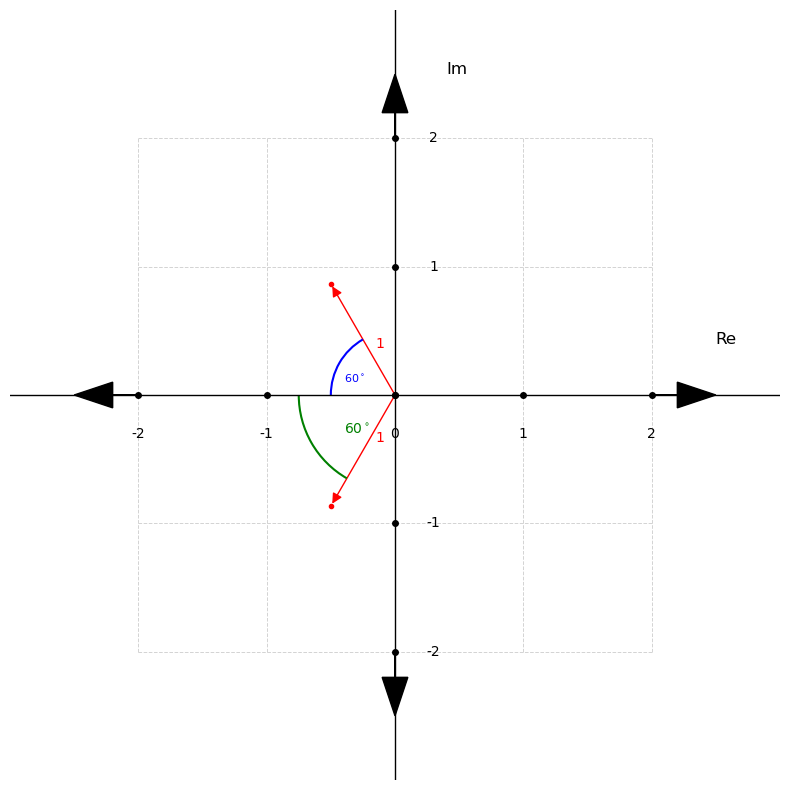

In [54]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [-1/2 + ((sqrt(3)/2) * 1j), -1/2 - ((sqrt(3)/2) * 1j)]

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=3)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)

theta_deg = np.degrees(np.arctan2(roots[0].imag, roots[0].real))
# # --- Arc showing the angle θ ---
arc = Arc((0, 0), 1, 1, angle=0, theta1=theta_deg, theta2=180, color="blue", linewidth=1.5)
ax.add_patch(arc)
plt.text(-0.4, 0.1, r"$60^\circ$", color='blue', fontsize=8)

theta_deg = np.degrees(np.arctan2(roots[1].imag, roots[1].real))
# # --- Arc showing the angle θ ---
arc = Arc((0, 0), 1.5, 1.5, angle=0, theta1=180, theta2=theta_deg, color="green", linewidth=1.5)
ax.add_patch(arc)
plt.text(-0.4, -0.3, r"$60^\circ$", color='green', fontsize=10)

## Adding the 'modulus'
plt.text(roots[0].real + 0.35, roots[0].imag - 0.5, "1", color='red', fontsize=10,
         rotation=360, rotation_mode='anchor')
## Adding the 'modulus'
plt.text(roots[1].real + 0.35, roots[1].imag + 0.5, "1", color='red', fontsize=10,
         rotation=360, rotation_mode='anchor')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

This is our argand diagram represented in respect to $r$ and $\theta$. But, it's not exactly correct.

Recall that the argument $\theta$ is "the angle that the modulus makes with the positive real axis". The key phrase is *positive real axis*.

Let's show this:

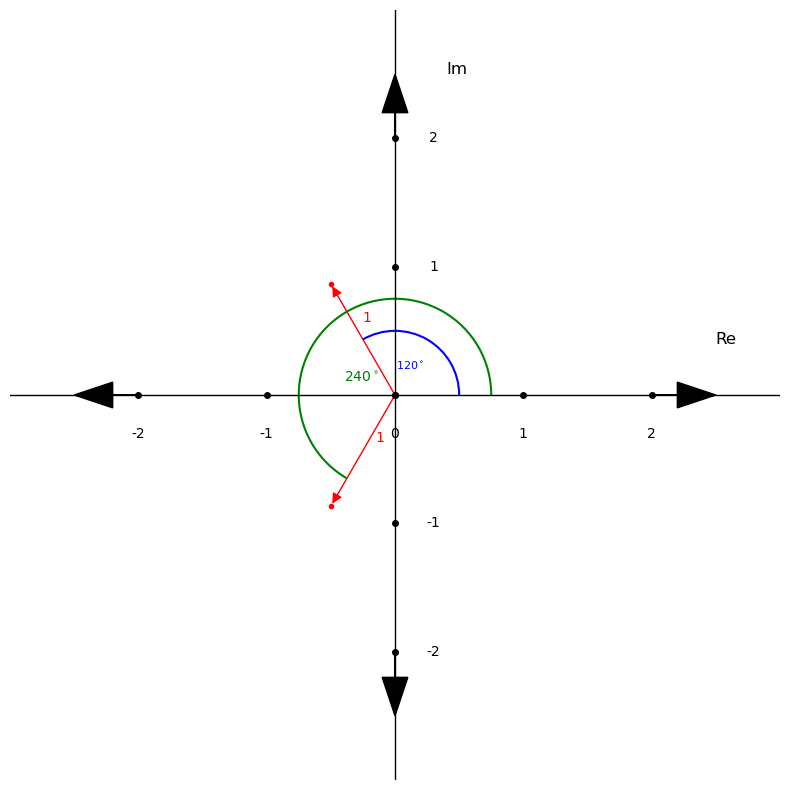

In [57]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [-1/2 + ((sqrt(3)/2) * 1j), -1/2 - ((sqrt(3)/2) * 1j)]

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=3)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)

theta_deg = np.degrees(np.arctan2(roots[0].imag, roots[0].real))
# # --- Arc showing the angle θ ---
arc = Arc((0, 0), 1, 1, angle=0, theta1=0, theta2=theta_deg, color="blue", linewidth=1.5)
ax.add_patch(arc)
plt.text(0.01, 0.2, r"$120^\circ$", color='blue', fontsize=8)

theta_deg = np.degrees(np.arctan2(roots[1].imag, roots[1].real))
# # --- Arc showing the angle θ ---
arc = Arc((0, 0), 1.5, 1.5, angle=0, theta1=0, theta2=theta_deg, color="green", linewidth=1.5)
ax.add_patch(arc)
plt.text(-0.4, 0.1, r"$240^\circ$", color='green', fontsize=10)

## Adding the 'modulus'
plt.text(roots[0].real + 0.25, roots[0].imag - 0.3, "1", color='red', fontsize=10,
         rotation=360, rotation_mode='anchor')
## Adding the 'modulus'
plt.text(roots[1].real + 0.35, roots[1].imag + 0.5, "1", color='red', fontsize=10,
         rotation=360, rotation_mode='anchor')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

As you can see, $\theta$ for $\dfrac{-1}{2} + \dfrac{\sqrt{3}\mathrm{i}}{2}$ becomes $120^\circ$ or $\dfrac{2\pi}{3}$ and $\theta$ for $\dfrac{-1}{2} - \dfrac{\sqrt{3}\mathrm{i}}{2}$ becomes $240^\circ$ or $\dfrac{4\pi}{3}$. 

In exponential form, this will be written as $e^{2\pi\mathrm{i}/3}$ and $e^{4\pi\mathrm{i}/3}$ respectively as $r = 1$.

This also helps us see the argument $\theta$ not just as angle but a *rotation* from the positive real axis and this is the mental model we need to understand roots of unity.

Let's do a quick experiment: we are going take the roots individually and compute their powers up to the third power. Then, we are going to see what happens in the argand diagram.

Starting with $e^{2\pi\mathrm{i}/3}$:

- We compute the zero power: $(e^{2\pi\mathrm{i}/3})^0 = e^{0} = 1$

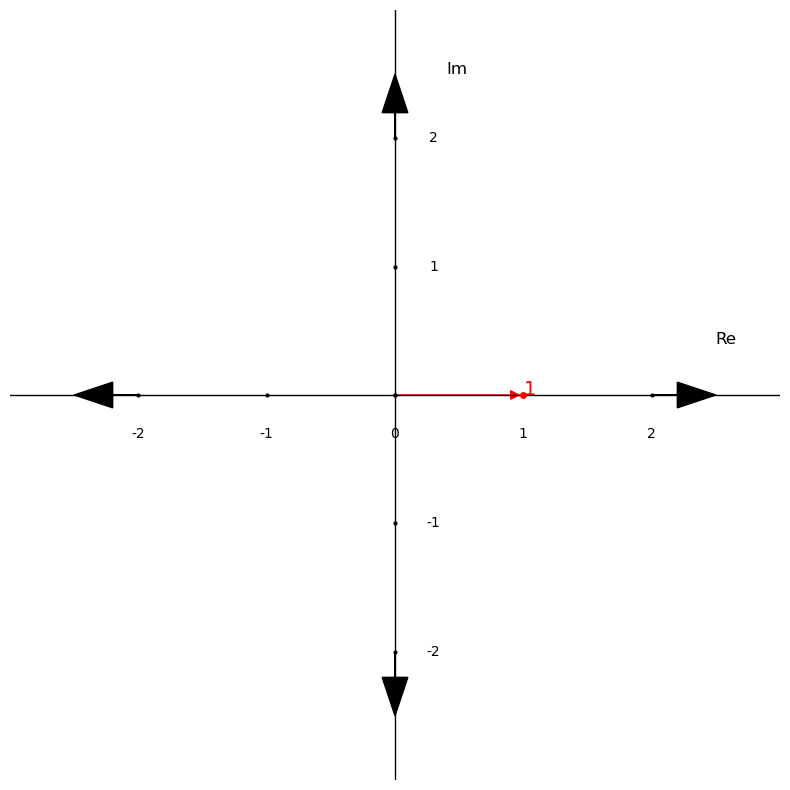

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# Labels for sides
plt.text(1, 0, r"$1$", color='red', fontsize=14, fontweight='bold')

# --- roots ---
roots = [1 + 0j]

# Dashed projection lines
for root in roots[:1]:
    plt.plot(root.real, root.imag, 'ro', markersize=4)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The first power: $(e^{2\pi\mathrm{i}/3})^1 = e^{2\pi\mathrm{i}/3}$

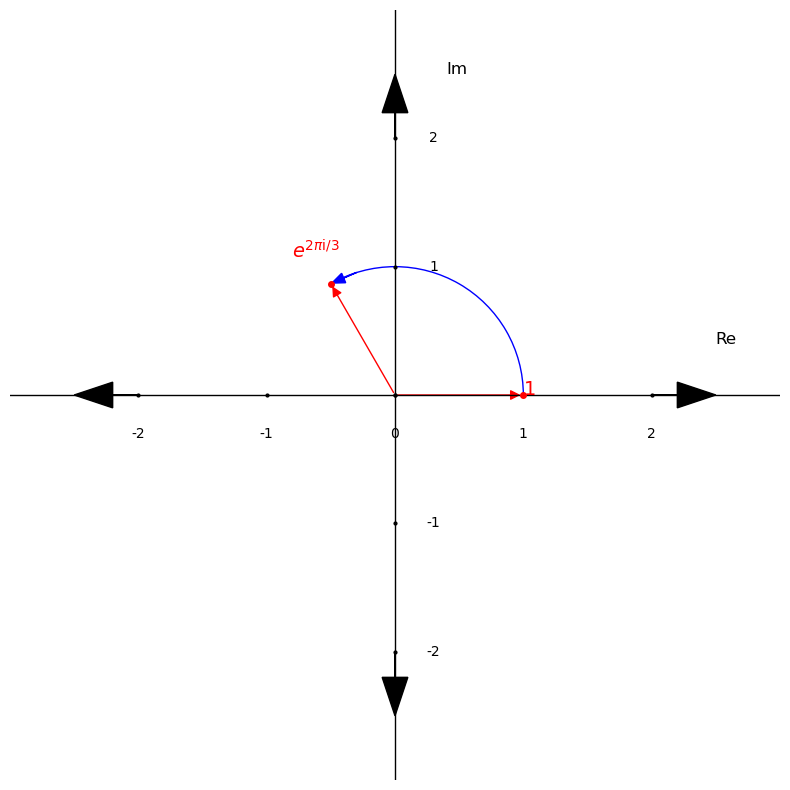

In [63]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [-1/2 + ((sqrt(3)/2) * 1j), -1/2 - ((sqrt(3)/2) * 1j), 1 + 0j]

# Labels for sides
plt.text(1, 0, r"$1$", color='red', fontsize=14, fontweight='bold')
plt.text(roots[0].real - 0.3, roots[0].imag + 0.2, r"$e^{2\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)


center = (0, 0)
radius = 1
theta1, theta2 = 0, 120   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

# Compute endpoint of arc (where the arrow will go)
theta = np.deg2rad(theta2)

# Draw arrowhead at the end of the arc
ax.arrow(-0.3, 0.955, 0.2*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The second power $(e^{2\pi\mathrm{i}/3})^2 = e^{4\pi\mathrm{i}/3}$

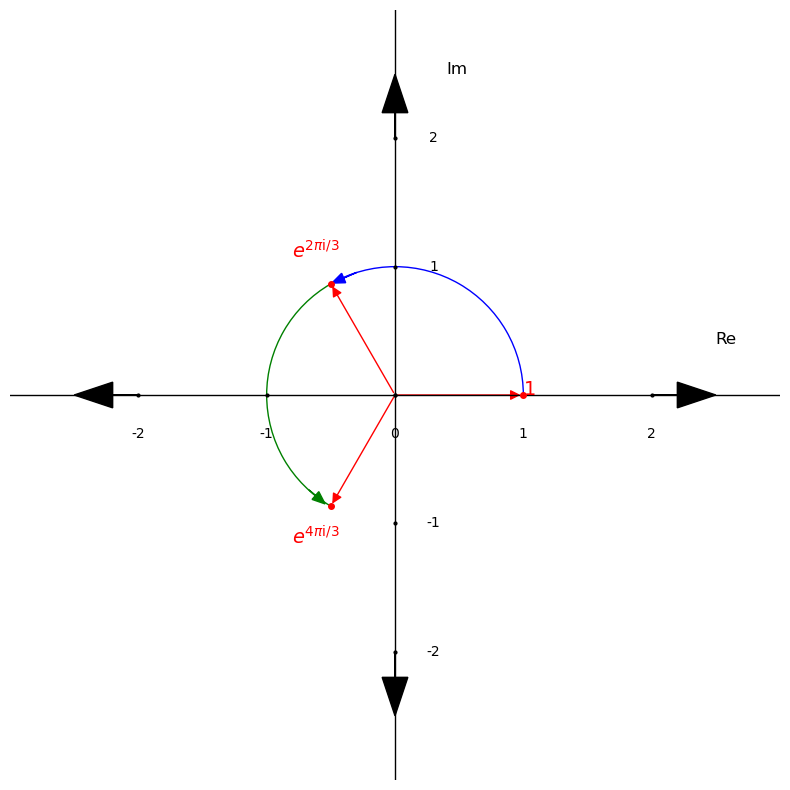

In [66]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)


# Draw a circle with radius 1 centered at (0,0)
# circle = plt.Circle((0, 0), 1, color='green', fill=False, linewidth=2)
# ax.add_patch(circle)

center = (0, 0)
radius = 1
theta1, theta2 = 0, 120   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

# Compute endpoint of arc (where the arrow will go)
theta = np.deg2rad(theta2)

# Draw arrowhead at the end of the arc
ax.arrow(-0.3, 0.955, 0.2*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

center = (0, 0)
radius = 1
theta1, theta2 = 0, 120   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=120, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

# Compute endpoint of arc (where the arrow will go)
theta = np.deg2rad(theta2)

# Draw arrowhead at the end of the arc
ax.arrow(-0.67, -0.74, -0.10*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')

# --- roots ---
roots = [-1/2 + ((sqrt(3)/2) * 1j), -1/2 - ((sqrt(3)/2) * 1j), 1 + 0j]

# Labels for sides
plt.text(roots[0].real - 0.3, roots[0].imag + 0.2, r"$e^{2\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')
plt.text(roots[1].real - 0.3, roots[1].imag - 0.3, r"$e^{4\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')
plt.text(roots[2].real, roots[2].imag, r"$1$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=4)
        # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The third power $(e^{2\pi\mathrm{i}/3})^3 = e^{6\pi\mathrm{i}/3}$

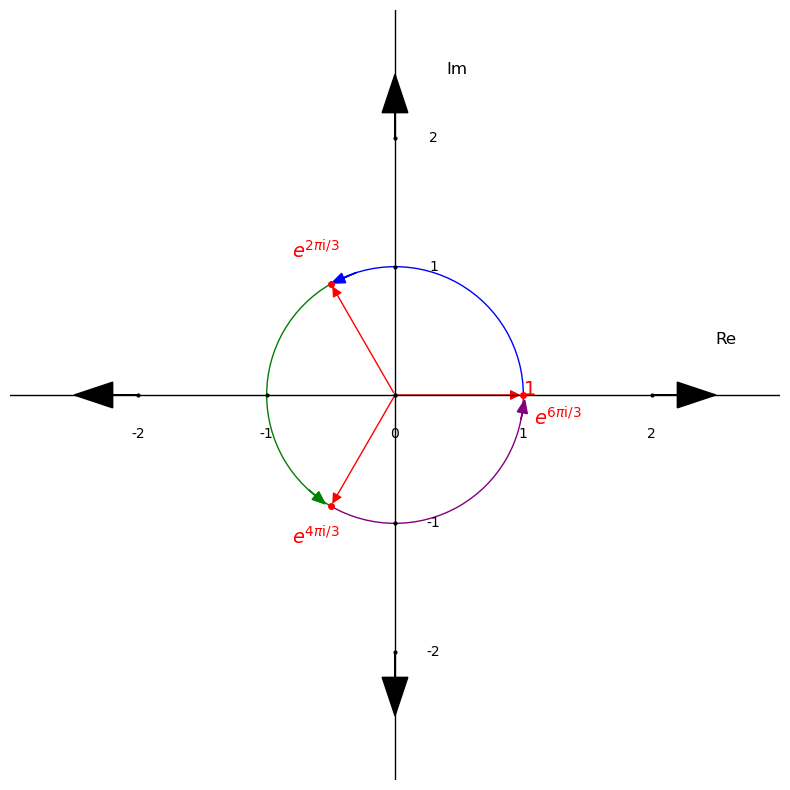

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)


center = (0, 0)
radius = 1
theta1, theta2 = 0, 120   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

# Compute endpoint of arc (where the arrow will go)
theta = np.deg2rad(theta2)

# Draw arrowhead at the end of the arc
ax.arrow(-0.3, 0.955, 0.2*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

center = (0, 0)
radius = 1
theta1, theta2 = 0, 120   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=120, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

# Compute endpoint of arc (where the arrow will go)
theta = np.deg2rad(theta2)

# Draw arrowhead at the end of the arc
ax.arrow(-0.67, -0.74, -0.10*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')

radius = 1
theta1, theta2 = 0, 120   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=240, theta1=theta1, theta2=theta2, color="purple")
ax.add_patch(arc)

# Compute endpoint of arc (where the arrow will go)
theta = np.deg2rad(theta2)

# Draw arrowhead at the end of the arc
ax.arrow(0.982, -0.19, 0.01, 0.06*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='purple', ec='purple')

# Labels for sides
plt.text(roots[0].real - 0.3, roots[0].imag + 0.2, r"$e^{2\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')
plt.text(roots[1].real - 0.3, roots[1].imag - 0.3, r"$e^{4\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')
plt.text(1.08, -0.24, r"$e^{6\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')
plt.text(1, 0, r"$1$", color='red', fontsize=14, fontweight='bold')

# --- roots ---
roots = [-1/2 + ((sqrt(3)/2) * 1j), -1/2 - ((sqrt(3)/2) * 1j), 1 + 0j]

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=4)
        # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

-----

Then, for $e^{4\pi\mathrm{i}/3}$:

- We compute the zero power: $(e^{4\pi\mathrm{i}/3})^0 = e^0 = 1$

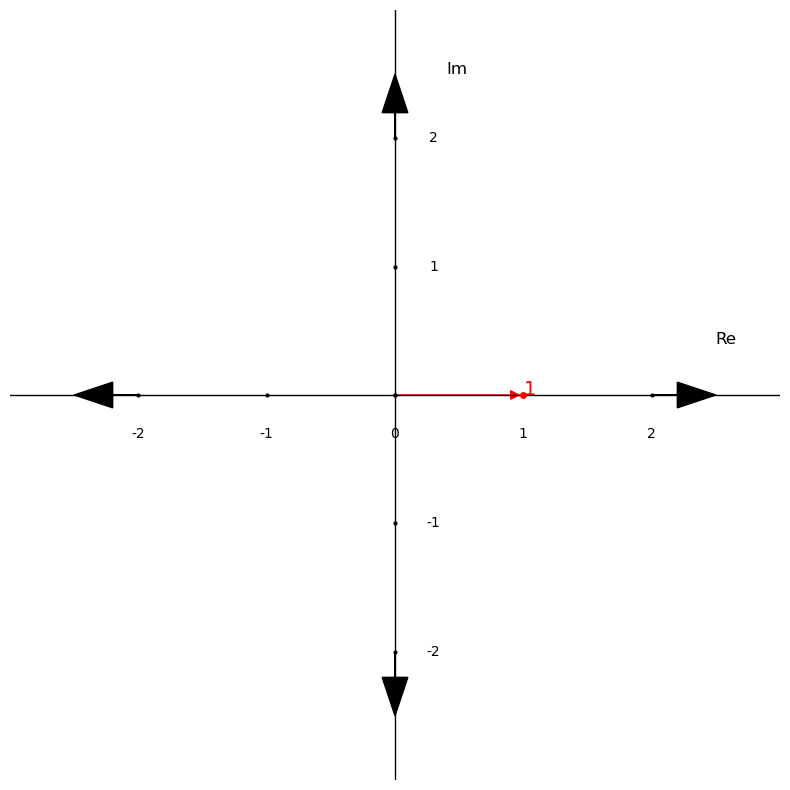

In [73]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# Labels for sides
plt.text(1, 0, r"$1$", color='red', fontsize=14, fontweight='bold')

# --- roots ---
roots = [1 + 0j]

# Dashed projection lines
for root in roots[:1]:
    plt.plot(root.real, root.imag, 'ro', markersize=4)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The first power: $(e^{4\pi\mathrm{i}/3})^1 = e^{4\pi\mathrm{i}/3}$

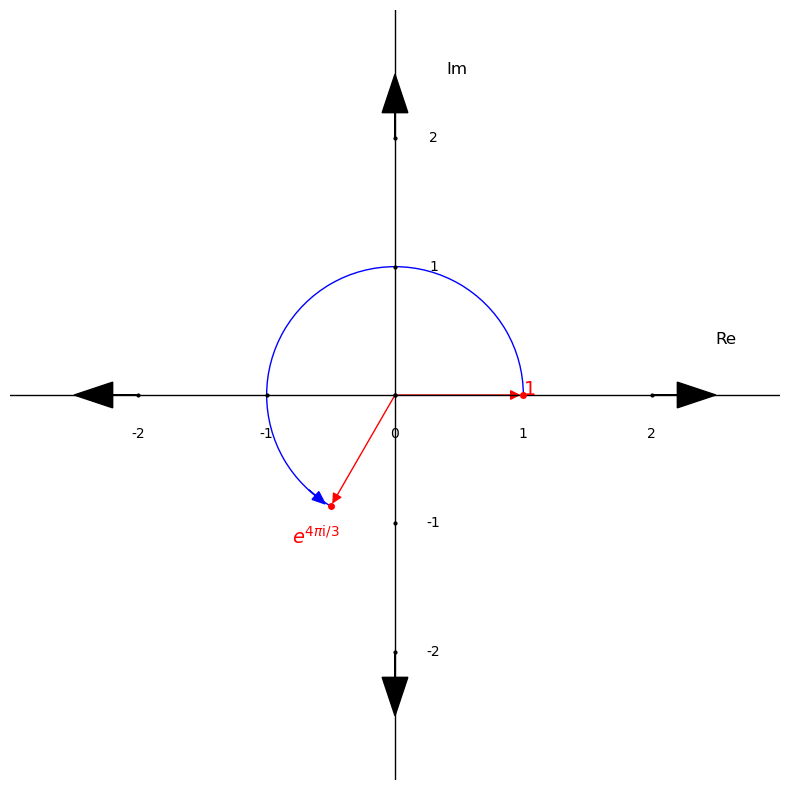

In [76]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [-1/2 + ((sqrt(3)/2) * 1j), -1/2 - ((sqrt(3)/2) * 1j), 1 + 0j]

# Labels for sides
plt.text(1, 0, r"$1$", color='red', fontsize=14, fontweight='bold')
plt.text(roots[1].real - 0.3, roots[1].imag - 0.3, r"$e^{4\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 240   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(-0.67, -0.74, -0.10*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The second power: $(e^{4\pi\mathrm{i}/3})^2 = e^{8\pi\mathrm{i}/3}$

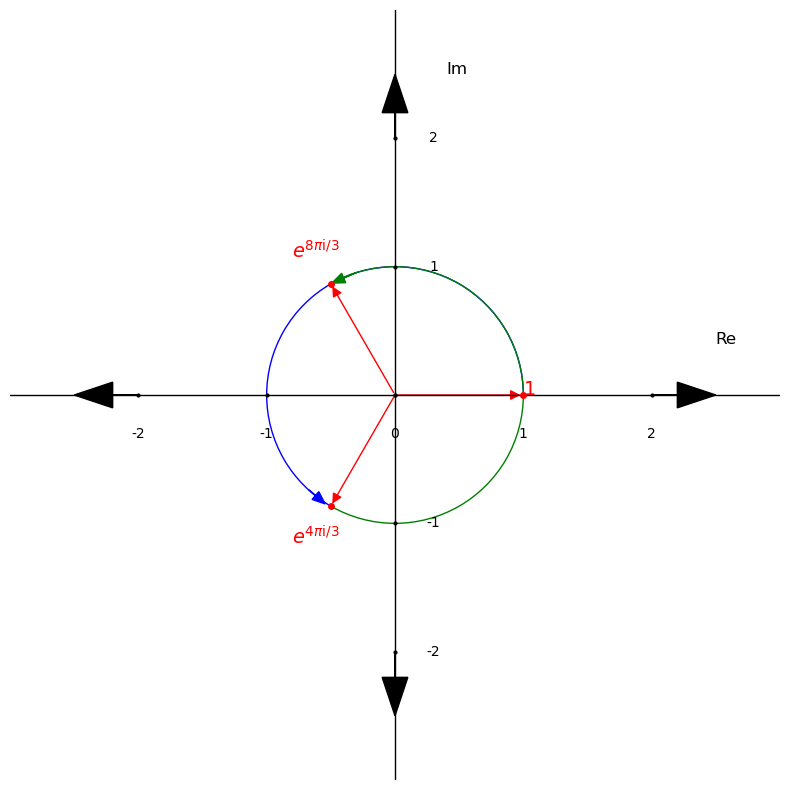

In [79]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [-1/2 + ((sqrt(3)/2) * 1j), -1/2 - ((sqrt(3)/2) * 1j), 1 + 0j]

# Labels for sides
plt.text(1, 0, r"$1$", color='red', fontsize=14, fontweight='bold')
plt.text(roots[1].real - 0.3, roots[1].imag - 0.3, r"$e^{4\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')
plt.text(roots[0].real - 0.3, roots[0].imag + 0.2, r"$e^{8\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 240   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(-0.67, -0.74, -0.10*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

theta1, theta2 = 0, 240   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=240, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(-0.3, 0.955, 0.2*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The third power: $(e^{4\pi\mathrm{i}/3})^3 = e^{12\pi\mathrm{i}/3}$

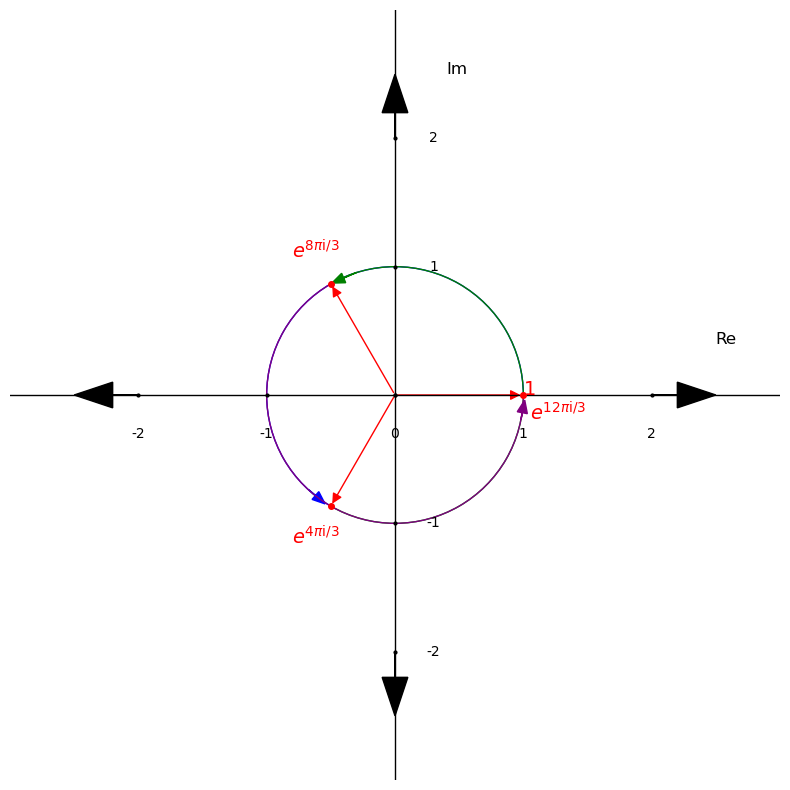

In [82]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [-1/2 + ((sqrt(3)/2) * 1j), -1/2 - ((sqrt(3)/2) * 1j), 1 + 0j]

# Labels for sides
plt.text(1, 0, r"$1$", color='red', fontsize=14, fontweight='bold')
plt.text(1.05, -0.2, r"$e^{12\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')
plt.text(roots[1].real - 0.3, roots[1].imag - 0.3, r"$e^{4\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')
plt.text(roots[0].real - 0.3, roots[0].imag + 0.2, r"$e^{8\pi\mathrm{i}/3}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 240   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(-0.67, -0.74, -0.10*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

theta1, theta2 = 0, 240   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=240, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(-0.3, 0.955, 0.2*np.cos(theta), -0.05*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=120, theta1=theta1, theta2=theta2, color="purple")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(0.982, -0.19, 0.01, 0.06*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='purple', ec='purple')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

----

What do you notice?

The powers go cycles back to $1$ at the third power. If we continued this cycle, you would notice that it doesn't just cycle back to $1$ at the third power but every power that's a multiple of $3$. I urge you to try this out.

Let's try this again for another polynomial.

Given the polynomial $P(x) = x^4 - 1$, let's the find the roots.

We get that:

- $P(x) = x^4 - 1 = (x^2 - 1)(x^2 + 1) = (x - 1)(x + 1)(x^2 + 1)$

Setting them to zero, we have that:
- $(x - 1) = 0$, $x = 1$
- $(x + 1) = 0$, $x = -1$
- $(x^2 + 1) = 0$, $x^2 = -1$, $x = \pm\sqrt{-1} = \pm\mathrm{i}$

Therefore, the roots of $P(x)$ are $1$, $-1$, $-\mathrm{i}$ and $\mathrm{i}$

Let's show them on the argand diagram.

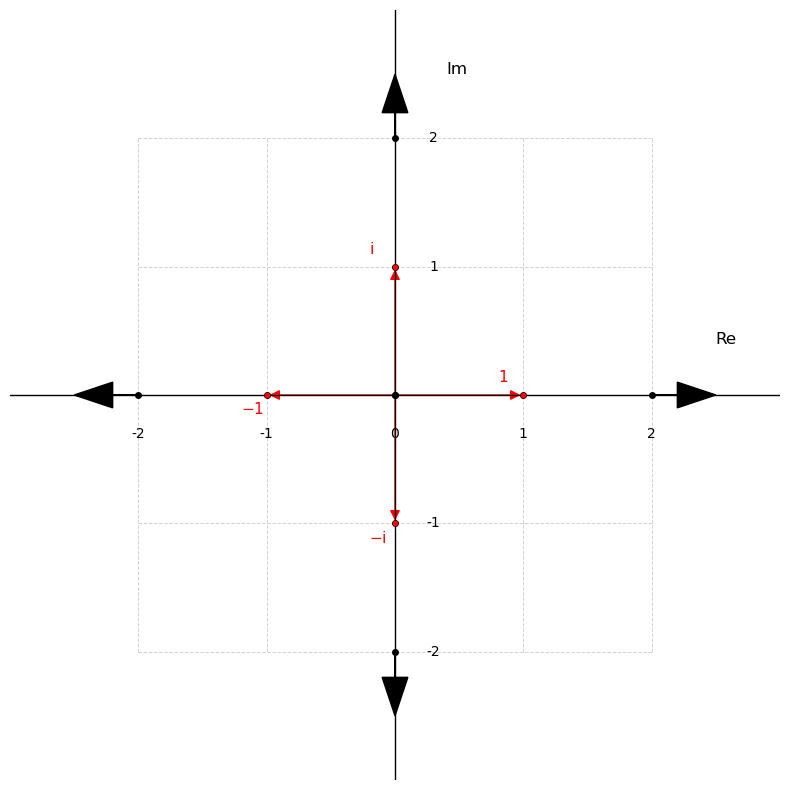

In [86]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, -1 + 0j, 0 + 1j, 0 + -1j]

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=3)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)

# Labels for sides
plt.text(roots[0].real - 0.2, roots[0].imag + 0.1, r"$1$", color='red', fontsize=11, fontweight='bold')
plt.text(roots[1].real - 0.2, roots[1].imag - 0.15, r"$-1$", color='red', fontsize=11, fontweight='bold')
plt.text(roots[2].real - 0.2, roots[2].imag + 0.1, r"$\mathrm{i}$", color='red', fontsize=11, fontweight='bold')
plt.text(roots[3].real - 0.2, roots[3].imag - 0.15, r"$-\mathrm{i}$", color='red', fontsize=11, fontweight='bold')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

----

Let's compute the modulus $r$ and argument $\theta$ for each of them.

- For $1$:
  - finding $r$: $r^2 = a^2 + b^2$, $\quad a = 1$, $\quad b = 0$, $\quad r^2 = 1^2 + 0^2 = 1$, $\quad r = 1$
  - finding $\theta$: $\theta = \tan^{-1}(\dfrac{b}{a}) = \tan^{-1}(\dfrac{0}{1}) = \tan^{-1}(0) = 0 = 0^\circ$ or $0\pi$
- For $-1$:
  - finding $r$: $r^2 = a^2 + b^2$, $\quad a = -1$, $\quad b = 0$, $\quad r^2 = -1^2 + 0^2 = 1$, $\quad r = 1$
  - finding $\theta$: $\theta = \tan^{-1}(\dfrac{b}{a}) = \tan^{-1}(\dfrac{0}{-1}) = \tan^{-1}(0) = 0 = 0^\circ$. $0^\circ$ from the positive x-axis is $180^\circ$ so $\theta = 180^\circ$ or $\pi$
- For $\mathrm{i}$:
  - finding $r$: $r^2 = a^2 + b^2$, $\quad a = 0$, $\quad b = 1$, $\quad r^2 = 0^2 + 1^2 = 1$, $\quad r = 1$
  - finding $\theta$: $\theta = \tan^{-1}(\dfrac{b}{a}) = \tan^{-1}(\dfrac{1}{0}) = 90^\circ$ or $\dfrac{\pi}{2}$. This looks like we are dividing 1 by 0 but trust me that's not the case. I will leave you to verify this yourself.
- For $-\mathrm{i}$:
  - finding $r$: $r^2 = a^2 + b^2$, $\quad a = 0$, $\quad b = -1$, $\quad r^2 = 0^2 + (-1)^2 = 1$, $\quad r = 1$
  - finding $\theta$: $\theta = \tan^{-1}(\dfrac{b}{a}) = \tan^{-1}(\dfrac{-1}{0}) = \tan^{-1}(0) = -90^\circ$. $-90^\circ$ from the positive x-axis is $270$ so $\theta = 270^\circ$ or $\dfrac{3\pi}{2}$

Converting them to exponential form, being that $r = 1$ for all roots, we have that:
-  $1 = e^{0\mathrm{i}} = e^0$
-  $-1 = e^{\pi\mathrm{i}}$
-  $\mathrm{i} = e^{\pi\mathrm{i}/{2}}$
-  $\mathrm{i} = e^{3\pi\mathrm{i}/{2}}$

Now, let's compute the powers of each root up the fourth power.

Starting with $e^0$:

- We compute the zero power $(e^0)^0 = e^0$. Notice that all the powers are equal as $(e^0)^0 = (e^0)^1 = (e^0)^2 = (e^0)^3 = (e^0)^4 = e^0$ so we have just one argand diagram showing the point without rotation.

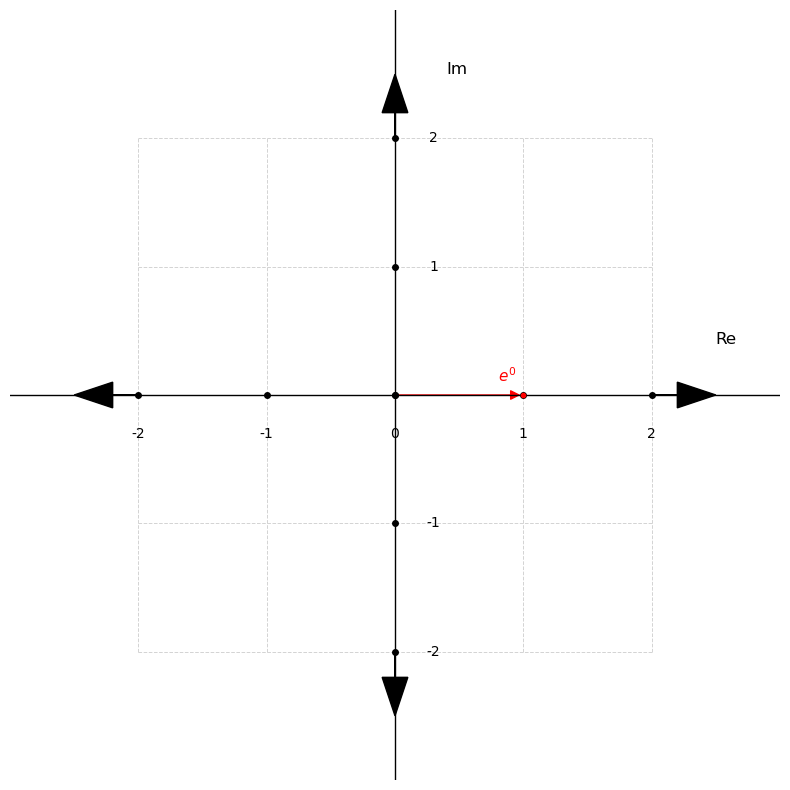

In [90]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j]

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=3)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)

# Labels for sides
plt.text(roots[0].real - 0.2, roots[0].imag + 0.1, r"$e^0$", color='red', fontsize=11, fontweight='bold')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

-----

For $e^{\pi\mathrm{i}}$:
- We compute the zero power: $(e^{\pi\mathrm{i}})^0 = e^0$

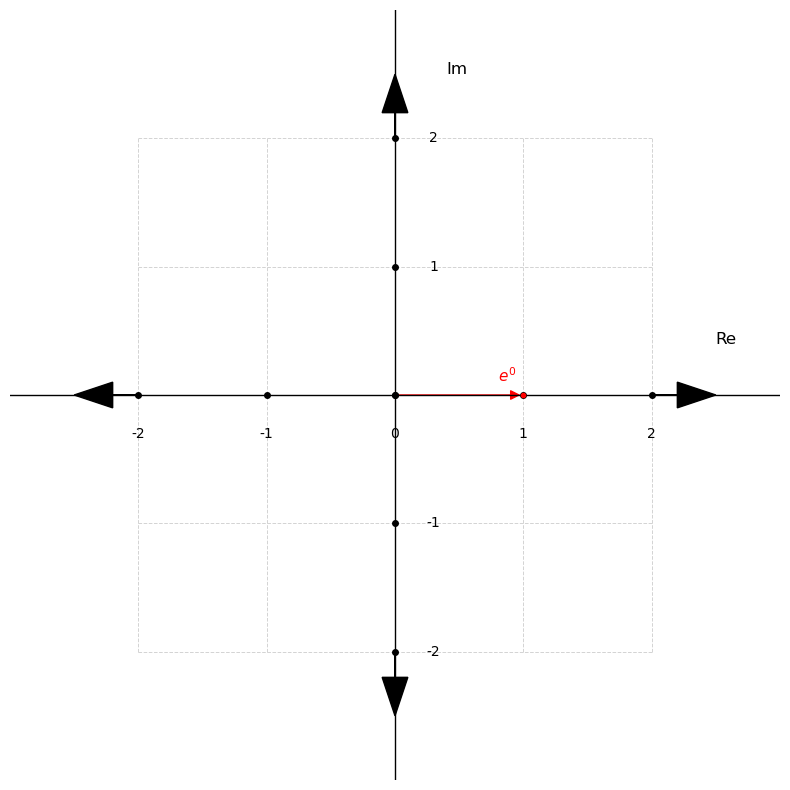

In [94]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j]

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=3)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)

# Labels for sides
plt.text(roots[0].real - 0.2, roots[0].imag + 0.1, r"$e^0$", color='red', fontsize=11, fontweight='bold')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The first power: $(e^{\pi\mathrm{i}})^1 = e^{\pi\mathrm{i}}$

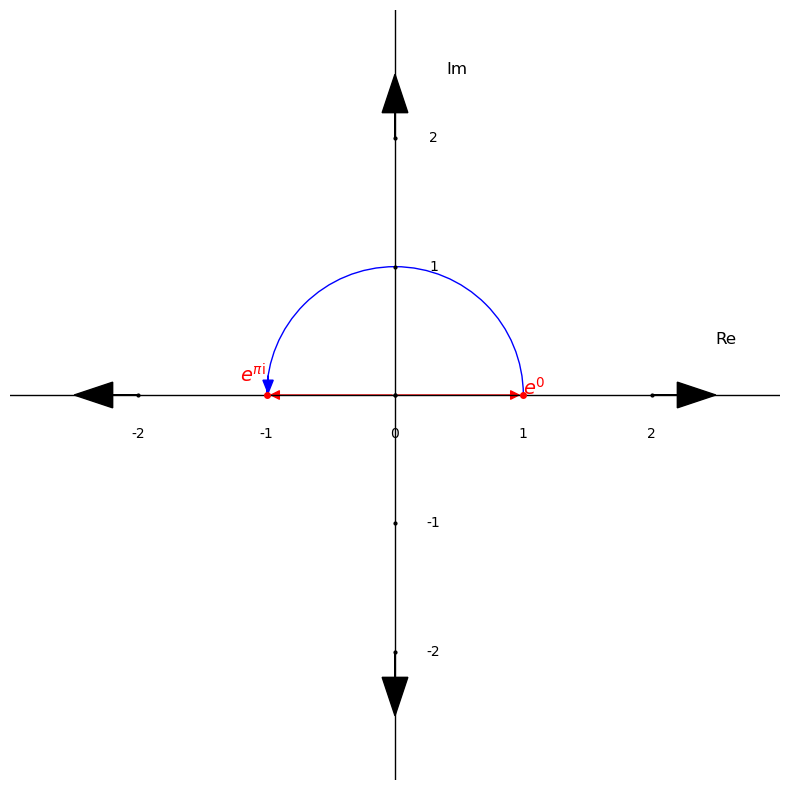

In [97]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, -1 + 0j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.21, 0.1, r"$e^{\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 180   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(-0.989, 0.15, 0*np.cos(theta), -0.04*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The second power: $(e^{\pi\mathrm{i}})^2 = e^{2\pi\mathrm{i}}$

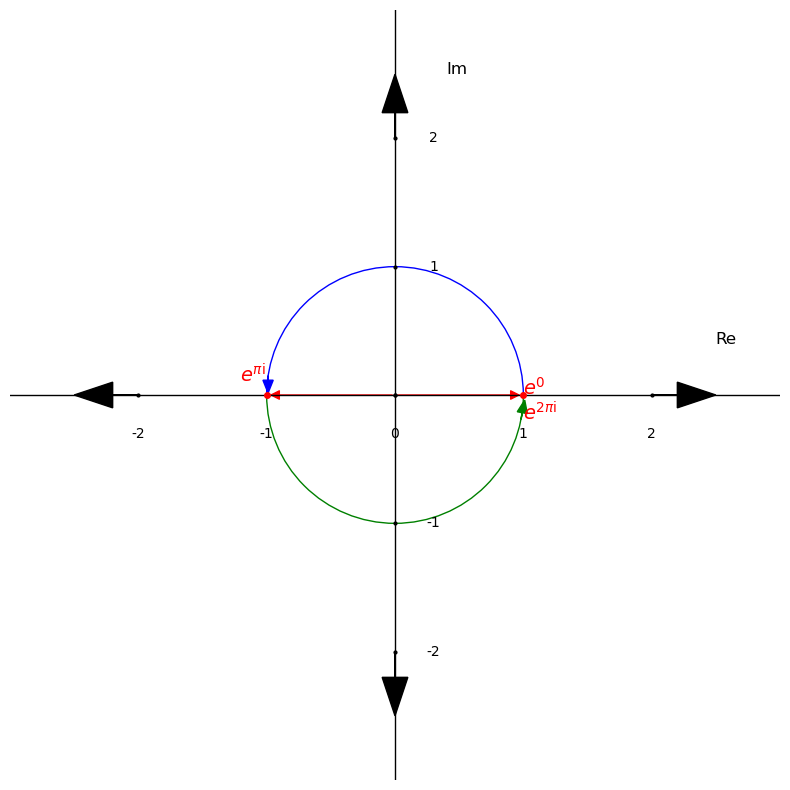

In [100]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, -1 + 0j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.21, 0.1, r"$e^{\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(1, -0.2, r"$e^{2\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 180   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(-0.989, 0.15, 0*np.cos(theta), -0.04*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

theta1, theta2 = 0, 180   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=180, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(0.982, -0.19, 0.01, 0.06*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The third power: $(e^{\pi\mathrm{i}})^3 = e^{3\pi\mathrm{i}}$

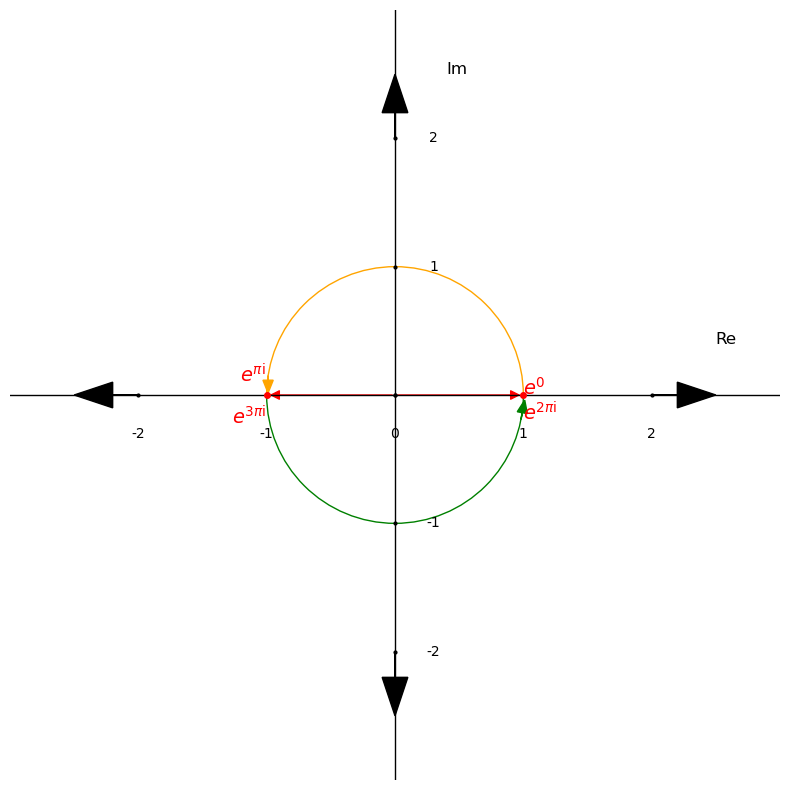

In [103]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, -1 + 0j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.21, 0.1, r"$e^{\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(1, -0.2, r"$e^{2\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.27, -0.23, r"$e^{3\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 180   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="orange")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(-0.989, 0.15, 0*np.cos(theta), -0.04*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='orange', ec='orange')

theta1, theta2 = 0, 180   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=180, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(0.982, -0.19, 0.01, 0.06*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The fourth power: $(e^{\pi\mathrm{i}})^4 = e^{4\pi\mathrm{i}}$

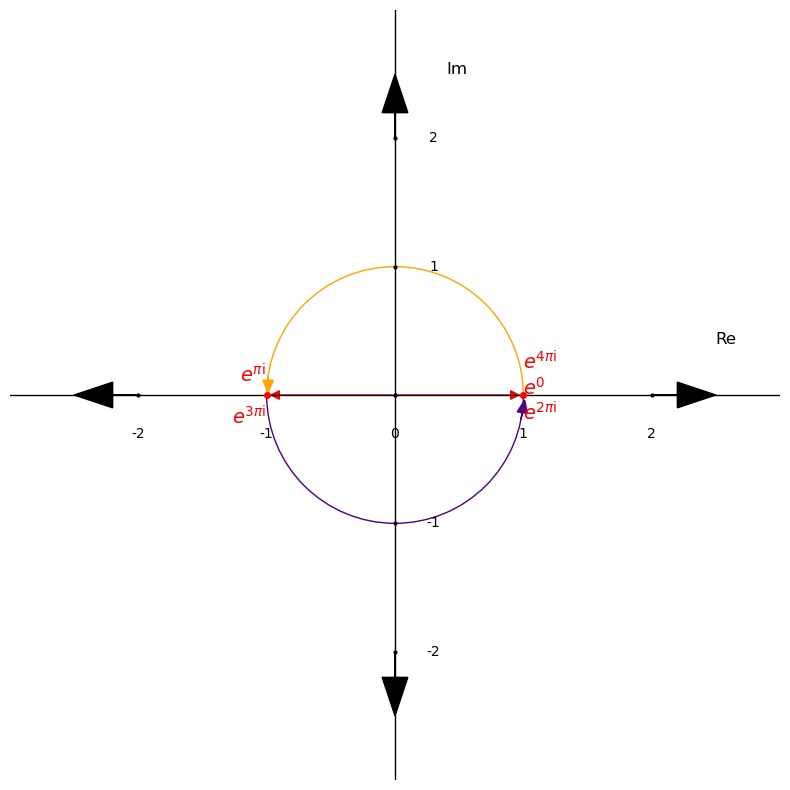

In [106]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, -1 + 0j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.21, 0.1, r"$e^{\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(1, -0.2, r"$e^{2\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.27, -0.23, r"$e^{3\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(1, 0.2, r"$e^{4\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 180   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="orange")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(-0.989, 0.15, 0*np.cos(theta), -0.04*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='orange', ec='orange')

theta1, theta2 = 0, 180   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=180, theta1=theta1, theta2=theta2, color="indigo")
ax.add_patch(arc)

theta = np.deg2rad(120)

# Draw arrowhead at the end of the arc
ax.arrow(0.982, -0.19, 0.01, 0.06*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='indigo', ec='indigo')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

-----

For $e^{\pi\mathrm{i}/{2}}$:

- We compute the zero power: $(e^{\pi\mathrm{i}/{2}})^0 = e^0$

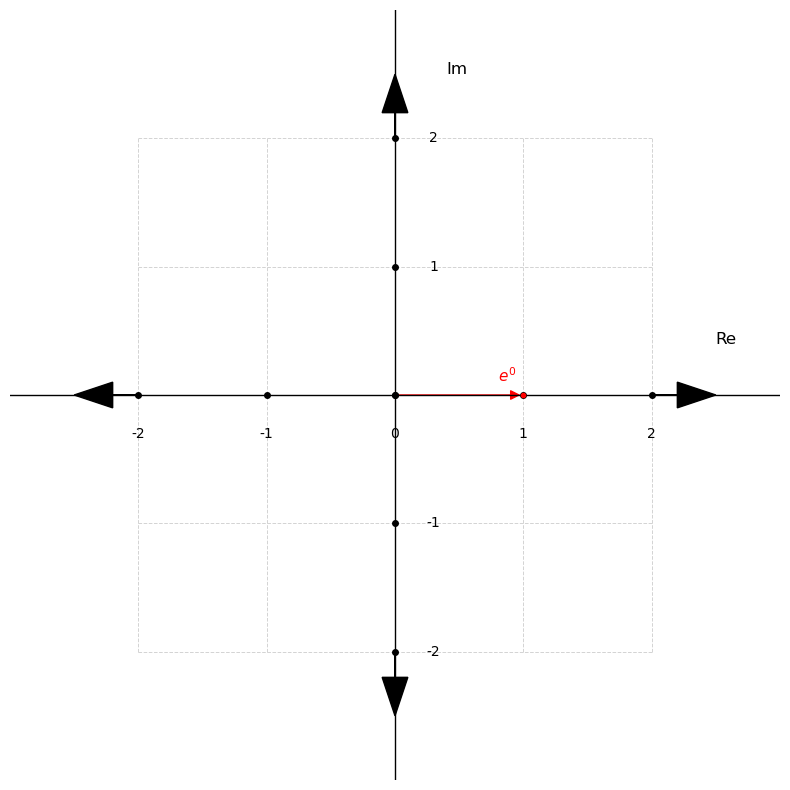

In [110]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j]

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=3)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)

# Labels for sides
plt.text(roots[0].real - 0.2, roots[0].imag + 0.1, r"$e^0$", color='red', fontsize=11, fontweight='bold')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The first power: $(e^{\pi\mathrm{i}/{2}})^1 = e^{\pi\mathrm{i}/{2}}$

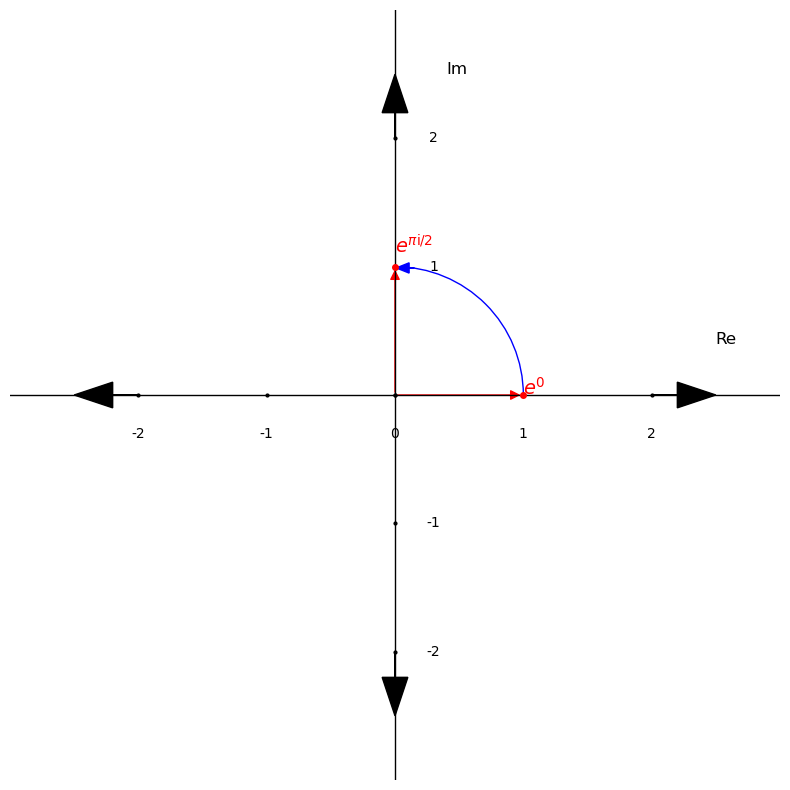

In [113]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, 0 + 1j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(0, 1.1, r"$e^{\pi\mathrm{i}/2}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 90   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(180)

# Draw arrowhead at the end of the arc
ax.arrow(0.15, 0.99, 0.04*np.cos(theta), 0*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The second power: $(e^{\pi\mathrm{i}/{2}})^2 = e^{\pi\mathrm{i}}$

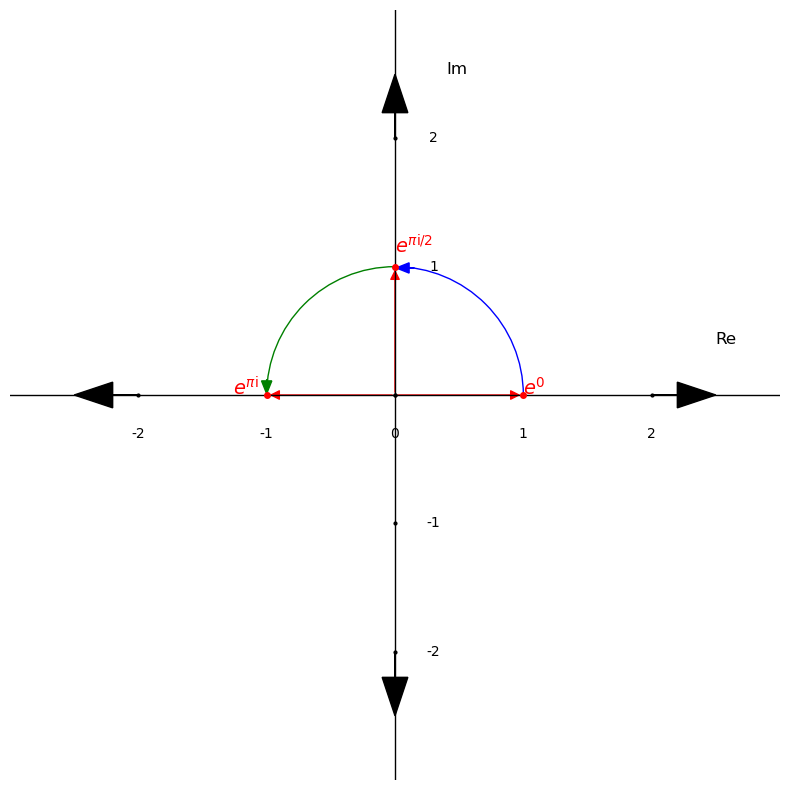

In [116]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, 0 + 1j, -1 + 0j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(0, 1.1, r"$e^{\pi\mathrm{i}/2}$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.26, 0, r"$e^{\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 90   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(180)

# Draw arrowhead at the end of the arc
ax.arrow(0.15, 0.99, 0.04*np.cos(theta), 0*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

theta1, theta2 = 0, 90   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=90, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(270)

# Draw arrowhead at the end of the arc
ax.arrow(-1, 0.12, 0.04*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The third power: $(e^{\pi\mathrm{i}/{2}})^3 = e^{3\pi\mathrm{i}/2}$

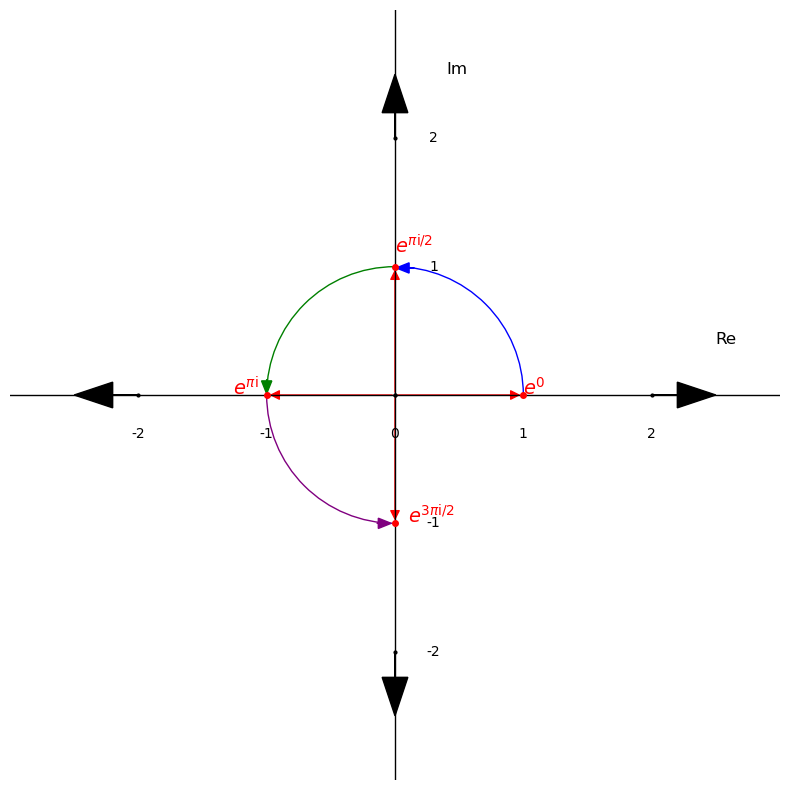

In [119]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, 0 + 1j, -1 + 0j, 0 + -1j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(0, 1.1, r"$e^{\pi\mathrm{i}/2}$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.26, 0, r"$e^{\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(0.1, -1, r"$e^{3\pi\mathrm{i}/2}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[3].real, roots[3].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[3].real, roots[3].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 90   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(180)

# Draw arrowhead at the end of the arc
ax.arrow(0.15, 0.99, 0.04*np.cos(theta), 0*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

theta1, theta2 = 0, 90   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=90, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(270)

# Draw arrowhead at the end of the arc
ax.arrow(-1, 0.12, 0.04*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')

theta1, theta2 = 0, 90   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=180, theta1=theta1, theta2=theta2, color="purple")
ax.add_patch(arc)

theta = np.deg2rad(0)

# Draw arrowhead at the end of the arc
ax.arrow(-0.14, -1, 0.01*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='purple', ec='purple')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The fourth power: $(e^{\pi\mathrm{i}/{2}})^4 = e^{2\pi\mathrm{i}}$

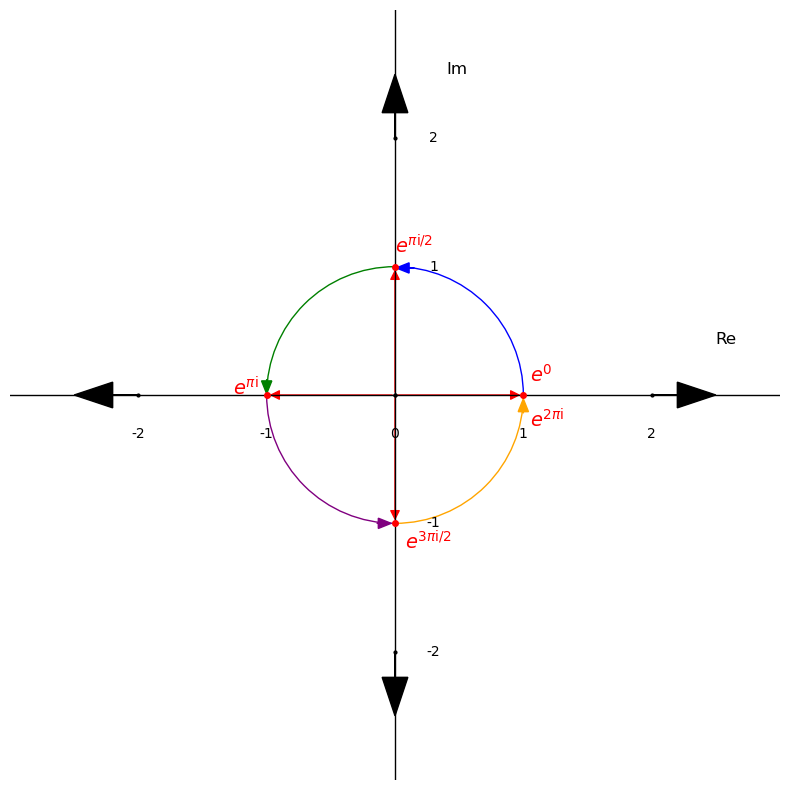

In [122]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, 0 + 1j, -1 + 0j, 0 + -1j]

# Labels for sides
plt.text(1.05, 0.1, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(0, 1.1, r"$e^{\pi\mathrm{i}/2}$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.26, 0, r"$e^{\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(0.08, -1.2, r"$e^{3\pi\mathrm{i}/2}$", color='red', fontsize=14, fontweight='bold')
plt.text(1.05, -0.25, r"$e^{2\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[3].real, roots[3].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[3].real, roots[3].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 90   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(180)

# Draw arrowhead at the end of the arc
ax.arrow(0.15, 0.99, 0.04*np.cos(theta), 0*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

theta1, theta2 = 0, 90   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=90, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(270)

# Draw arrowhead at the end of the arc
ax.arrow(-1, 0.12, 0.04*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')

theta1, theta2 = 0, 90   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=180, theta1=theta1, theta2=theta2, color="purple")
ax.add_patch(arc)

theta = np.deg2rad(0)

# Draw arrowhead at the end of the arc
ax.arrow(-0.14, -1, 0.01*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='purple', ec='purple')

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=270, theta1=theta1, theta2=theta2, color="orange")
ax.add_patch(arc)

theta = np.deg2rad(90)

# Draw arrowhead at the end of the arc
ax.arrow(1, -0.14, 0.01*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='orange', ec='orange')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

-----

For $e^{3\pi\mathrm{i}/{2}}$:

- We compute the zero power: $(e^{3\pi\mathrm{i}/{2}})^0 = e^0$

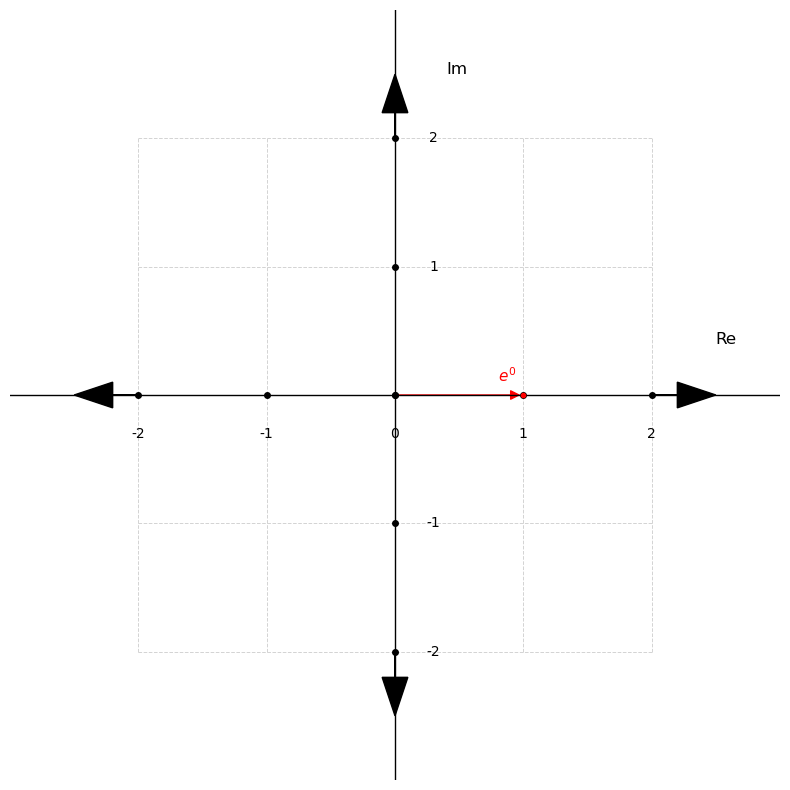

In [126]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw grid ---
grid_points = np.arange(-limit, limit + 1, 1)
for x in grid_points:
    plt.plot([x, x], [-limit, limit], color='lightgray', linestyle='--', linewidth=0.7)
for y in grid_points:
    plt.plot([-limit, limit], [y, y], color='lightgray', linestyle='--', linewidth=0.7)

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=4)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=4)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j]

# Dashed projection lines
for root in roots:
    plt.plot(root.real, root.imag, 'ro', markersize=3)
    # --- Angled arrow for vector z ---
    arrow = FancyArrowPatch((0, 0), (root.real, root.imag),
                            arrowstyle='-|>', mutation_scale=15,
                            color='red', linewidth=1)
    ax.add_patch(arrow)

# Labels for sides
plt.text(roots[0].real - 0.2, roots[0].imag + 0.1, r"$e^0$", color='red', fontsize=11, fontweight='bold')

# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The first power: $(e^{3\pi\mathrm{i}/{2}})^1 = e^{3\pi\mathrm{i}/{2}}$

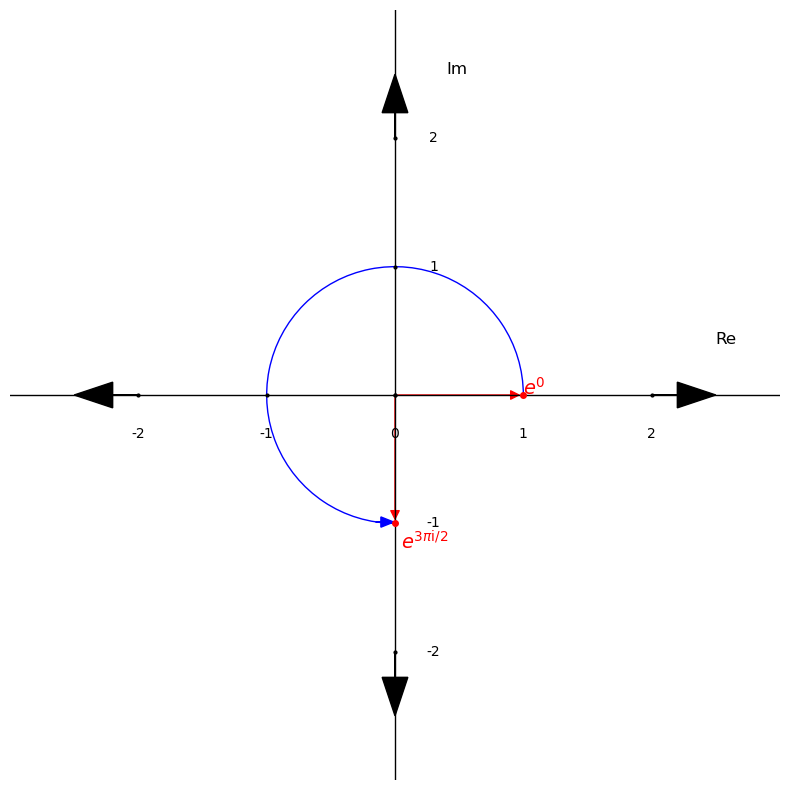

In [129]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, 0 + -1j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(0.05, -1.2, r"$e^{3\pi\mathrm{i}/{2}}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 270   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(0)

# Draw arrowhead at the end of the arc
ax.arrow(-0.15, -0.99, 0.04*np.cos(theta), 0*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The second power: $(e^{3\pi\mathrm{i}/{2}})^2 = e^{3\pi\mathrm{i}}$

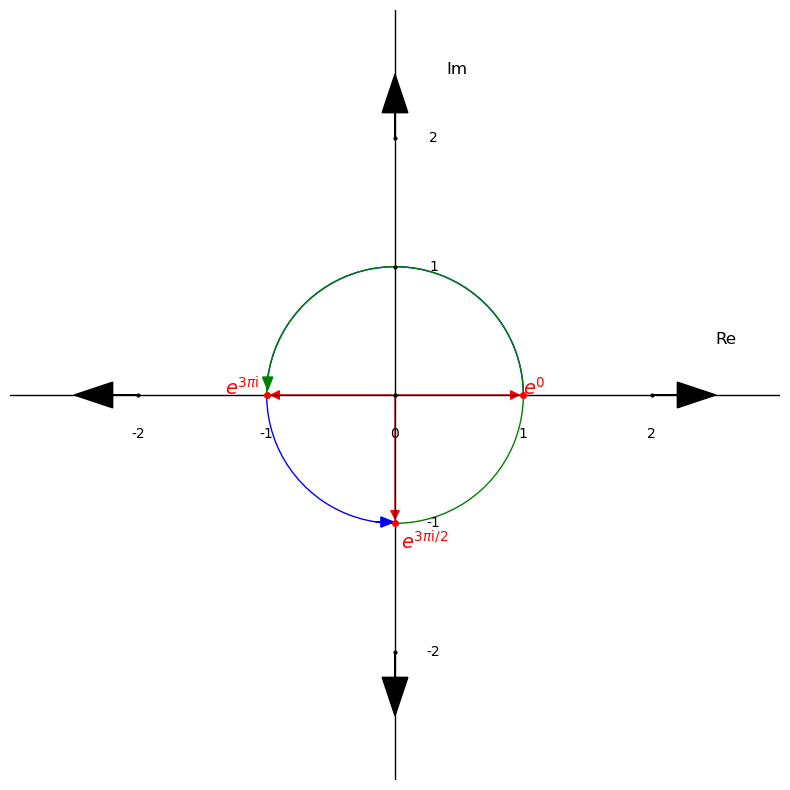

In [133]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, 0 + -1j, -1 + 0j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(0.05, -1.2, r"$e^{3\pi\mathrm{i}/{2}}$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.324, 0, r"$e^{3\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 270   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(0)

# Draw arrowhead at the end of the arc
ax.arrow(-0.15, -0.99, 0.04*np.cos(theta), 0*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

theta1, theta2 = 0, 270   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=270, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(270)

# Draw arrowhead at the end of the arc
ax.arrow(-0.992, 0.15, 0.01*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The third power: $(e^{3\pi\mathrm{i}/{2}})^3 = e^{9\pi\mathrm{i}/2}$

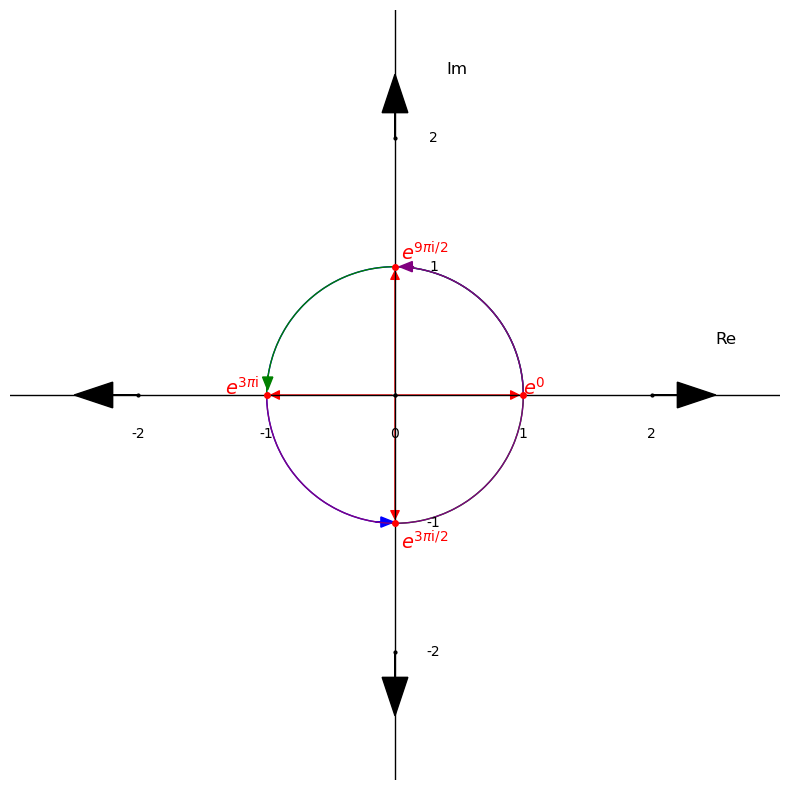

In [181]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, 0 + -1j, -1 + 0j, 0 + 1j]

# Labels for sides
plt.text(1, 0, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(0.05, -1.2, r"$e^{3\pi\mathrm{i}/{2}}$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.324, 0, r"$e^{3\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(0.05, 1.05, r"$e^{9\pi\mathrm{i}/{2}}$", color='red', fontsize=14, fontweight='bold')

# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[3].real, roots[3].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[3].real, roots[3].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 270   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(0)

# Draw arrowhead at the end of the arc
ax.arrow(-0.15, -0.99, 0.04*np.cos(theta), 0*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

theta1, theta2 = 0, 270   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=270, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(270)

# Draw arrowhead at the end of the arc
ax.arrow(-0.992, 0.15, 0.01*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=180, theta1=theta1, theta2=theta2, color="purple")
ax.add_patch(arc)

theta = np.deg2rad(180)

# Draw arrowhead at the end of the arc
ax.arrow(0.145, 1, 0.01*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='purple', ec='purple')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()

- The fourth power: $(e^{3\pi\mathrm{i}/{2}})^4 = e^{6\pi\mathrm{i}}$

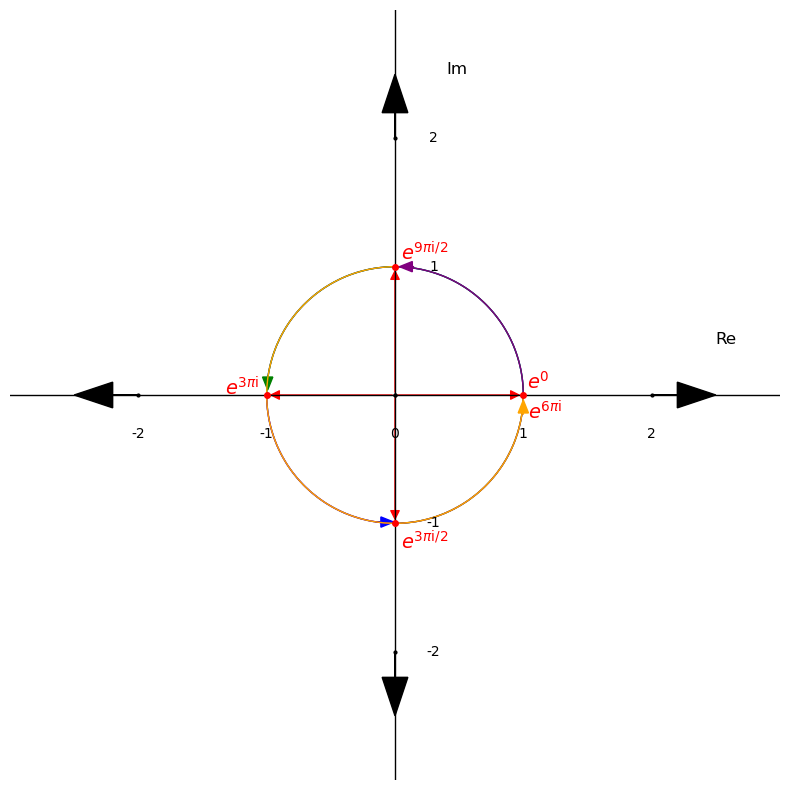

In [231]:
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt

limit = 2
plt.figure(figsize=(10, 10))

# --- Draw main axes ---
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# --- Arrowheads ---
plt.arrow(limit, 0, 0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(-limit, 0, -0.2, 0, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, limit, 0, 0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')
plt.arrow(0, -limit, 0, -0.2, head_width=0.2, head_length=0.3, fc='black', ec='black')

# --- Remove frame ---
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

# --- Set limits ---
plt.xlim(-limit - 1, limit + 1)
plt.ylim(-limit - 1, limit + 1)
ax.set_aspect('equal')

# --- Add tick dots and labels ---
for t in grid_points:
    plt.plot(t, 0, 'ko', markersize=2)   # x-axis dots
    plt.plot(0, t, 'ko', markersize=2)   # y-axis dots
    plt.text(t, -0.3, str(t), ha='center', va='center', fontsize=10)
    if t != 0:
        plt.text(0.3, t, str(t), ha='center', va='center', fontsize=10)

# --- roots ---
roots = [1 + 0j, 0 + -1j, -1 + 0j, 0 + 1j]

# Labels for sides
plt.text(1.03, 0.05, r"$e^0$", color='red', fontsize=14, fontweight='bold')
plt.text(0.05, -1.2, r"$e^{3\pi\mathrm{i}/{2}}$", color='red', fontsize=14, fontweight='bold')
plt.text(-1.324, 0, r"$e^{3\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')
plt.text(0.05, 1.05, r"$e^{9\pi\mathrm{i}/{2}}$", color='red', fontsize=14, fontweight='bold')
plt.text(1.04, -0.19, r"$e^{6\pi\mathrm{i}}$", color='red', fontsize=14, fontweight='bold')


# Dashed projection lines
plt.plot(roots[0].real, roots[0].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[0].real, roots[0].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[1].real, roots[1].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[1].real, roots[1].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[2].real, roots[2].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[2].real, roots[2].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

plt.plot(roots[3].real, roots[3].imag, 'ro', markersize=4)
# --- Angled arrow for vector z ---
arrow = FancyArrowPatch((0, 0), (roots[3].real, roots[3].imag),
                        arrowstyle='-|>', mutation_scale=15,
                        color='red', linewidth=1)
ax.add_patch(arrow)

theta1, theta2 = 0, 270   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=0, theta1=theta1, theta2=theta2, color="blue")
ax.add_patch(arc)

theta = np.deg2rad(0)

# Draw arrowhead at the end of the arc
ax.arrow(-0.15, -0.99, 0.04*np.cos(theta), 0*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='blue', ec='blue')

theta1, theta2 = 0, 270   # arc goes from 0 to 120°

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=270, theta1=theta1, theta2=theta2, color="green")
ax.add_patch(arc)

theta = np.deg2rad(270)

# Draw arrowhead at the end of the arc
ax.arrow(-0.992, 0.15, 0.01*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='green', ec='green')

# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=180, theta1=theta1, theta2=theta2, color="purple")
ax.add_patch(arc)

theta = np.deg2rad(180)

# Draw arrowhead at the end of the arc
ax.arrow(0.145, 1, 0.01*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='purple', ec='purple')


# Draw an arc (center at (0,0), width=2, height=2, from 0° to 180°)
arc = Arc((0, 0), 2, 2, angle=90, theta1=theta1, theta2=theta2, color="orange")
ax.add_patch(arc)

theta = np.deg2rad(90)

# Draw arrowhead at the end of the arc
ax.arrow(1, -0.15, 0.01*np.cos(theta), 0.01*np.sin(theta),
         head_width=0.08, head_length=0.1, fc='orange', ec='orange')
    
# --- Axis labels ---
plt.text(limit + 0.5, 0.4, 'Re', fontsize=12)
plt.text(0.4, limit + 0.5, 'Im', fontsize=12)

# --- Remove default ticks ---
ax.set_xticks([])
ax.set_yticks([])

plt.show()